<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/13a_lstm_tuning_compacto_FULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB13a_FULL — Tuning compacto da LSTM por célula

Pipeline PPCOMP/DM — ramo `_FULL` · Borg 2019 completo por célula.

## 1. Papel do notebook no pipeline

O `NB13a_FULL` é um notebook intermediário e opcional derivado do `NB13_FULL`. Sua função é avaliar, de forma controlada, se um tuning compacto da arquitetura LSTM altera a decisão metodológica de manter os escores do modelo tabular vencedor do `NB11_FULL` como entrada preferencial do `NB14_FULL`.

Este notebook **não substitui** o `NB13_FULL`; ele aprofunda apenas a hipótese de que a LSTM poderia ter ficado abaixo do baseline tabular por falta de ajuste leve de hiperparâmetros. Por isso, o escopo é deliberadamente restrito:

- execução por `cell_id`, sem concatenação temporal das células;
- cenário vencedor do `NB11_FULL` por célula;
- conjunto de atributos vencedor do `NB11_FULL` por célula;
- corte treino/teste herdado dos artefatos upstream;
- comparação principal contra o F1 médio TSCV do vencedor tabular do `NB11_FULL`;
- decisão conservadora para alimentar o `NB14_FULL`.

## 2. Pergunta respondida

> Um tuning compacto da LSTM, por célula, melhora o resultado do `NB13_FULL` e supera o vencedor tabular do `NB11_FULL` com margem suficiente para alterar a fonte de escores do `NB14_FULL`?

Para manter compatibilidade direta com o `NB13_FULL` já executado, este notebook separa dois conceitos:

- `decision`: decisão **nominal**, governada apenas pela margem `ΔF1 >= 0,0300` sobre o `NB11_FULL`, preservando a semântica do `NB13_FULL`;
- `nb14_score_source_recommendation`: campo **soberano para integração com o NB14_FULL**, que incorpora a leitura de robustez por `Δ/SE`.

Assim, se a LSTM ajustada superar a margem nominal, mas ficar com `Δ/SE < 2,0`, o campo `decision` registra que os escores LSTM podem alimentar análise/sensibilidade, enquanto `nb14_score_source_recommendation` mantém o `NB11_FULL` como fonte primária para o `NB14_FULL`. O valor `Δ/SE` é descritivo, calculado sobre o F1 do Stage 2, e não constitui teste pareado contra o `NB11_FULL`.

Contrato de integração:

```text
NB14_FULL deve consumir nb14_score_source_recommendation, não decision.
```

## 3. Entradas esperadas

### Artefatos obrigatórios do NB11_FULL

- `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_winner_model.json`
- `04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate/11_FULL_metrics_summary_by_cell.csv`

### Artefatos preferenciais do NB11_FULL por célula

- `04-reports/99_FULL_downstream/11_FULL_model_baselines/cell_<id>/11_FULL_model_input_features_cell_<id>.parquet`
- ou `11_FULL_sequence_input_features_cell_<id>.parquet`

### Fallback controlado, se a matriz sequencial do NB11_FULL estiver ausente

- `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_series_states_cell_<id>.parquet`
- `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_decisions_cell_<id>.csv`

## 4. Saídas geradas

As saídas são gravadas em:

```text
04-reports/99_FULL_downstream/13a_FULL_lstm_tuning/
```

Por célula:

- `13a_FULL_lstm_tuning_stage1_results_cell_<id>.csv`
- `13a_FULL_lstm_tuning_stage1_agg_cell_<id>.csv`
- `13a_FULL_lstm_tuning_stage2_results_cell_<id>.csv`
- `13a_FULL_lstm_tuning_stage2_agg_cell_<id>.csv`
- `13a_FULL_lstm_tuning_fixed_results_cell_<id>.csv`
- `13a_FULL_lstm_tuning_scores_cell_<id>.parquet`
- `13a_FULL_lstm_tuning_best_config_cell_<id>.json`
- `13a_FULL_lstm_tuning_decision_to_nb14_cell_<id>.json`
- `13a_FULL_lstm_tuning_summary_cell_<id>.json`
- `13a_FULL_lstm_tuning_issues_cell_<id>.csv`

No agregado:

- `13a_FULL_lstm_tuning_stage1_agg_by_cell.csv`
- `13a_FULL_lstm_tuning_stage2_agg_by_cell.csv`
- `13a_FULL_lstm_tuning_fixed_results_by_cell.csv`
- `13a_FULL_lstm_tuning_decision_to_nb14_by_cell.csv`
- `13a_FULL_lstm_tuning_delta_vs_NB11_FULL_by_cell.csv`
- `13a_FULL_lstm_tuning_delta_vs_NB13_FULL_by_cell.csv`
- `13a_FULL_delta_vs_canonical.csv`
- `13a_FULL_pilot_validation_summary.csv`
- `figures/13a_FULL_lstm_tuning_best_vs_nb11_by_cell.png`
- `13a_FULL_lstm_tuning_summary.json`
- `13a_FULL_artifact_manifest_sha256.csv`

## 4. Diferenças em relação ao NB13a canônico

1. Entrada por célula Borg (`cell_a` ... `cell_h`).
2. Usa exclusivamente o cenário/feature set vencedor do `NB11_FULL` por célula.
3. Não cria novos cenários nem novos atributos.
4. Não recalcula corte 80/20 por fração; exige split ou `train_cutoff_idx` herdado.
5. Executa tuning em dois estágios: varredura compacta com uma semente e confirmação das melhores configurações com três sementes.
6. Gera `decision` nominal compatível com o `NB13_FULL` e `nb14_score_source_recommendation` como campo soberano para o `NB14_FULL`.
7. Acrescenta governança específica do `_FULL`: `pilot_validation_summary`, `delta_vs_canonical`, contrato explícito para o NB14 e figura comparativa citável.
8. Explicita a decisão de custo por `EXECUTION_SCOPE`: `pilot_smoke`, `allcells_gpu` ou `selected_near_miss_cpu`.

## 5. Travas metodológicas

- A unidade experimental é a célula Borg.
- Não concatenar células como série única.
- Não escrever em `03-features`.
- Não sobrescrever artefatos `13_FULL_*`.
- Não usar `state`, `target`, `episode`, `threshold`, `split`, `bucket_start` ou qualquer campo de rótulo como feature.
- Não rederivar o corte por `floor(len * 0.8)` se o upstream não trouxer split/corte herdado.


## 6. Modos de execução recomendados

- `EXECUTION_SCOPE = "pilot_smoke"`: padrão seguro do notebook; roda `cell_a` em modo `SMOKE` para validar caminhos, schema e geração de artefatos.
- `EXECUTION_SCOPE = "allcells_gpu"`: execução oficial completa, recomendada se houver GPU; roda as oito células em `FINAL_COMPACT`.
- `EXECUTION_SCOPE = "selected_near_miss_cpu"`: alternativa econômica quando só houver CPU; roda `cell_b` e `cell_g`, por terem sido as células em que a LSTM mais se aproximou no NB13_FULL. Esse uso deve ser documentado no MD final como execução seletiva defensiva, não como fechamento completo do `_FULL`.


[TensorFlow] Determinismo operacional habilitado quando suportado pelo backend.
NB13a_FULL iniciado em: 2026-06-26 21:31:10
Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
NB13A_FULL_VERSION: COMPACT_TUNING_BY_CELL_WINNER_ONLY_GOVERNED
EXECUTION_SCOPE: allcells_gpu
Treinos LSTM estimados: 1704
DRIVE_ROOT       : /content/drive/MyDrive/Mestrado
STAGE10_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics
STAGE11_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines
STAGE11_AGG_DIR  : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate
STAGE13_FULL_DIR : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/13_FULL_lstm
STAGE13A_DIR     : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/13a_FULL_lstm_tuning
AGGREGATE_DIR    : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/13a_FULL_lstm_tuni

,artifact,path,resolved,required,role
0,winner,/content/drive/MyDrive/Mestrado/04-reports/99_...,True,False,"contexto_global_opcional; se ausente, usa metr..."
1,summary,/content/drive/MyDrive/Mestrado/04-reports/99_...,True,False,contexto_descritivo_opcional
2,metrics_summary,/content/drive/MyDrive/Mestrado/04-reports/99_...,True,True,fonte_soberana_para_vencedor_por_célula
3,modelability,/content/drive/MyDrive/Mestrado/04-reports/99_...,True,False,"gate_modelabilidade; se ausente, validação_local"
4,feature_sets,/content/drive/MyDrive/Mestrado/04-reports/99_...,True,False,catálogo_de_features; fallback temporal_core/r...
5,schema,/content/drive/MyDrive/Mestrado/04-reports/99_...,True,False,schema_agregado; fallback schemas por célula


,cell_id,scenario_label,feature_set,model,n_folds_valid,n_features,features,accuracy_tscv_mean,accuracy_tscv_std,precision_tscv_mean,precision_tscv_std,recall_tscv_mean,recall_tscv_std,f1_tscv_mean,f1_tscv_std,roc_auc_tscv_mean,roc_auc_tscv_std,average_precision_tscv_mean,average_precision_tscv_std,brier_tscv_mean,brier_tscv_std,false_alerts_per_day_tscv_mean,false_alerts_per_day_tscv_std,is_winner_tscv,status_modelagem,is_modelable,modelability_source,modelability_reason,status_modelagem_nb04_raw,status_modelagem_nb04_normalized,status_modelagem_nb11_counts,is_modelable_by_nb11_counts,official_gate_pending,official_gate_veto,n_positivos_train,n_positivos_test,min_train_positives_for_modeling,min_test_positives_for_modeling
0,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,0.770147,0.063925,0.313790,0.123110,0.582254,0.150741,0.398273,0.133186,0.767357,0.072995,0.418698,0.225440,0.160073,0.034441,51.163458,18.134343,True,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
1,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,hist_gradient_boosting,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,0.823654,0.047707,0.370557,0.137546,0.444364,0.192206,0.380992,0.144285,0.746987,0.061988,0.414367,0.194118,0.128041,0.026541,30.162480,16.706465,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
2,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,random_forest,5,14,fail_rate|n_events|n_failed|n_machines|n_colle...,0.881892,0.035031,0.519618,0.130580,0.298824,0.220808,0.362919,0.198029,0.749326,0.073167,0.417738,0.162751,0.098581,0.022217,8.597716,3.143236,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
3,a,cell_a_W5_K24_H12_train_m2s_P1,raw_7,logistic_regression,5,7,fail_rate|n_events|n_failed|n_machines|n_colle...,0.707341,0.057746,0.255359,0.087954,0.631445,0.163162,0.355897,0.108852,0.730840,0.073514,0.372685,0.160377,0.197537,0.024180,70.895922,19.808049,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30
4,a,cell_a_W5_K24_H12_train_m2s_P1,raw_7,random_forest,5,7,fail_rate|n_events|n_failed|n_machines|n_colle...,0.848287,0.028156,0.363982,0.064131,0.272785,0.122565,0.303160,0.110365,0.677676,0.049448,0.303750,0.076464,0.123333,0.015409,16.067863,4.607117,False,modelavel,True,nb04_gate_consultive_plus_nb11_counts,gate_nb04_raw=HAS_EPISODE_SUPPORT_PENDING_NB06...,HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS,pendente,modelavel,True,True,False,890,144,30,30


[NB13a_FULL_lstm_tuning] Backup de artefatos anteriores criado em: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/13a_FULL_lstm_tuning/aggregate/_backup_previous_artifacts/backup_20260626_213140
[NB13a_FULL_lstm_tuning] [RESUME] cell_a: artefatos já existem; carregando do disco (sem retreinar).
[NB13a_FULL_lstm_tuning] [RESUME] cell_b: artefatos já existem; carregando do disco (sem retreinar).
[NB13a_FULL_lstm_tuning] [RESUME] cell_c: artefatos já existem; carregando do disco (sem retreinar).
[NB13a_FULL_lstm_tuning] [RESUME] cell_d: artefatos já existem; carregando do disco (sem retreinar).
[NB13a_FULL_lstm_tuning] [RESUME] cell_e: artefatos já existem; carregando do disco (sem retreinar).
[NB13a_FULL_lstm_tuning] [RESUME] cell_f: artefatos já existem; carregando do disco (sem retreinar).
[NB13a_FULL_lstm_tuning] Processando cell_g...
[NB13a_FULL_lstm_tuning] cell_g stage1_screening trial 1/36: seq12__units8__drop0.10__lr0.001 seed=42
[NB13a_FULL_lstm_tuning] cell_g sta

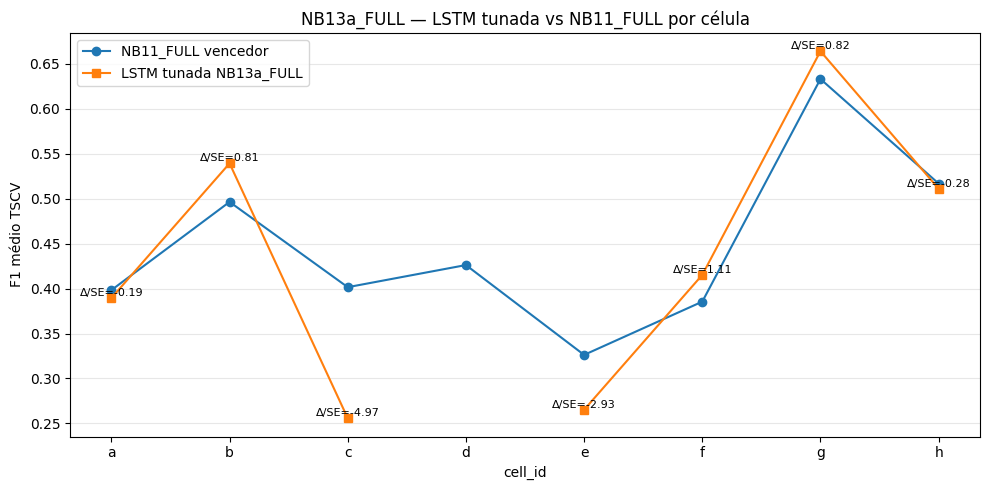


Resumo NB13a_FULL:
{
  "notebook": "NB13a_FULL",
  "version": "COMPACT_TUNING_BY_CELL_WINNER_ONLY_GOVERNED",
  "run_timestamp": "2026-06-26 21:31:40",
  "run_timestamp_file": "20260626_213140",
  "active_cells": [
    "a",
    "b",
    "c",
    "d",
    "e",
    "f",
    "g",
    "h"
  ],
  "config": {
    "run_mode": "FINAL_COMPACT",
    "execution_scope": "allcells_gpu",
    "scenario_scope": "winner_only",
    "feature_sets_to_evaluate": [
      "winner_feature_set"
    ],
    "classification_threshold": 0.5,
    "min_delta_f1_to_feed_nb14": 0.03,
    "validation_fraction_from_train": 0.2,
    "save_keras_models": false,
    "keras_verbose": 0,
    "backup_previous_outputs": false,
    "allow_nb10_reconstruction_fallback": true,
    "fail_if_missing_inherited_split": true,
    "modelable_only": true,
    "sequence_length_grid": [
      12,
      24,
      36
    ],
    "lstm_units_grid": [
      8,
      16
    ],
    "dropout_grid": [
      0.1,
      0.2,
      0.3
    ],
    "le

,cell_id,decision,nb14_score_source_recommendation,robustness_interpretation,reason,nb11_f1_tscv_mean,nb13_full_best_f1_tscv_mean,best_lstm_tuned_f1_tscv_mean,best_lstm_tuned_f1_se,delta_f1_tuned_minus_nb11,delta_f1_tuned_minus_nb13_full,delta_over_lstm_tuned_f1_se,min_delta_f1_to_feed_nb14,uncertainty_note
0,a,keep_nb11_scores_for_nb14,nb11_primary,sem_ganho_suficiente_sobre_nb11,Ganho insuficiente sobre NB11_FULL: ΔF1=-0.0088.,0.398273,0.397656,0.389505,0.047142,-0.008768,-0.008151,-0.186000,0.03,delta/SE é leitura descritiva baseada na varia...
1,b,lstm_scores_can_feed_nb14,nb11_primary_lstm_optional_sensitivity,ganho_nominal_acima_da_margem_mas_dentro_da_in...,"LSTM tunada superou NB11_FULL por ΔF1=0.0429, ...",0.496409,0.549358,0.539296,0.053042,0.042887,-0.010063,0.808546,0.03,delta/SE é leitura descritiva baseada na varia...
2,c,keep_nb11_scores_for_nb14,nb11_primary,sem_ganho_suficiente_sobre_nb11,Ganho insuficiente sobre NB11_FULL: ΔF1=-0.1458.,0.401552,0.268093,0.255777,0.029329,-0.145776,-0.012316,-4.970293,0.03,delta/SE é leitura descritiva baseada na varia...
3,d,keep_nb11_scores_for_nb14,nb11_primary,sem_lstm_tunada_valida,LSTM tunada sem resultado TSCV válido no Stage 2.,0.426165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,e,keep_nb11_scores_for_nb14,nb11_primary,sem_ganho_suficiente_sobre_nb11,Ganho insuficiente sobre NB11_FULL: ΔF1=-0.0611.,0.326230,0.247590,0.265177,0.020858,-0.061053,0.017587,-2.927056,0.03,delta/SE é leitura descritiva baseada na varia...
5,f,keep_nb11_scores_for_nb14,nb11_primary,sem_ganho_suficiente_sobre_nb11,Ganho insuficiente sobre NB11_FULL: ΔF1=0.0298.,0.385456,0.382684,0.415219,0.026905,0.029763,0.032536,1.106259,0.03,delta/SE é leitura descritiva baseada na varia...
6,g,lstm_scores_can_feed_nb14,nb11_primary_lstm_optional_sensitivity,ganho_nominal_acima_da_margem_mas_dentro_da_in...,"LSTM tunada superou NB11_FULL por ΔF1=0.0309, ...",0.633126,NaN,0.664066,0.037517,0.030940,NaN,0.824685,0.03,delta/SE é leitura descritiva baseada na varia...
7,h,keep_nb11_scores_for_nb14,nb11_primary,sem_ganho_suficiente_sobre_nb11,Ganho insuficiente sobre NB11_FULL: ΔF1=-0.0058.,0.516797,NaN,0.511037,0.020566,-0.005760,NaN,-0.280047,0.03,delta/SE é leitura descritiva baseada na varia...



Gates de validação/governança:


,check_name,status,observed,expected,details
0,execution_errors,OK,0,0,Falhas fatais por célula durante a execução pr...
1,nb11_winner_present,OK,"missing=[]; completed=['a', 'b', 'c', 'd', 'e'...",winner NB11_FULL resolvido para cada célula pr...,Garante que o NB13a_FULL tunou somente o cenár...
2,positive_floor_alignment_30_30,OK,0,0,Linhas válidas do Stage 2 devem respeitar o pi...
3,stage2_valid_cell_coverage,WARN,"[a, b, c, e, f, g, h]","[a, b, c, d, e, f, g, h]",Cobertura esperada depende do escopo: SMOKE=ce...
4,leakage_detected,OK,0,0,Qualquer detecção de leakage deve bloquear a s...
5,no_canonical_or_nb13_overwrite,OK,/content/drive/MyDrive/Mestrado/04-reports/99_...,13a_FULL_lstm_tuning separado de 13_FULL_lstm ...,Confirma isolamento de artefatos do NB13a_FULL.
6,decision_rows_present,OK,8,>= 1 e idealmente 8,Cada célula processada deve produzir decisão n...
7,nb14_contract_field,OK,has_contract_col=True; ambiguous_primary_rows=0,NB14_FULL consome nb14_score_source_recommenda...,Garante conciliação com o NB13_FULL sem reexec...



Delta canônico ↔ FULL:


,notebook_full,notebook_canonical,change_type,description,justified,justification
0,13a_lstm_tuning_FULL.ipynb,13a_lstm_tuning_compacto.ipynb,I/O_PATH,Troca de entradas e saídas canônicas por artef...,True,Necessário para isolar o ramo _FULL e impedir ...
1,13a_lstm_tuning_FULL.ipynb,13a_lstm_tuning_compacto.ipynb,CELL_LOOP,"Execução parametrizada por cell_id, sem concat...",True,A célula Borg é a unidade experimental do _FULL.
2,13a_lstm_tuning_FULL.ipynb,13a_lstm_tuning_compacto.ipynb,OUTPUT_PREFIX,Todos os artefatos usam prefixo 13a_FULL_* e p...,True,Evita sobrescrita de NB13_FULL e de artefatos ...
3,13a_lstm_tuning_FULL.ipynb,13a_lstm_tuning_compacto.ipynb,AGGREGATION_BY_CELL,Consolidação por célula e aggregate; decisão p...,True,Preserva a heterogeneidade operacional do Borg...
4,13a_lstm_tuning_FULL.ipynb,13a_lstm_tuning_compacto.ipynb,REPORTING_ONLY,Contrato de decisão alinhado ao NB13_FULL: dec...,True,Evita reexecutar o NB13_FULL e preserva compat...
5,13a_lstm_tuning_FULL.ipynb,13a_lstm_tuning_compacto.ipynb,REPORTING_ONLY,"Grade de units compactada de [8, 16, 32] para ...",True,Decisão explícita de custo/ROI: reduz espaço e...



Manifesto de artefatos:


,relative_path,size_bytes,mtime_iso,sha256
0,aggregate/13a_FULL_backup_marker_20260626_1149...,160,2026-06-26T11:50:03,b35611ea1fb6c45442224a5067b5809f0d6d6287ae939b...
1,aggregate/13a_FULL_backup_marker_20260626_1901...,160,2026-06-26T19:02:23,35983eeaae317e1aa7f8134f78b8e246c8ff220ff073cd...
2,aggregate/13a_FULL_backup_marker_20260626_2131...,160,2026-06-26T21:32:15,9eeecac19d81f4a22b639c2cb48244c4e80ff398ee30e7...
3,aggregate/13a_FULL_delta_vs_canonical.csv,1621,2026-06-26T22:57:16,7dc017db297ad26322fa155ee25afb7e6756bf2f495f18...
4,aggregate/13a_FULL_lstm_tuning_decision_to_nb1...,3279,2026-06-26T22:57:16,0f793175d6d016bb01a0d1aa270ffdaa11d1d6c12d6a97...
5,aggregate/13a_FULL_lstm_tuning_delta_vs_NB11_F...,1348,2026-06-26T22:57:16,27840214ecb8e601868d4ca22b885094f92013b690aad1...
6,aggregate/13a_FULL_lstm_tuning_delta_vs_NB13_F...,1268,2026-06-26T22:57:16,04cde84f38db0a3976fee33c1ef7b20a19b6184b9c50ca...
7,aggregate/13a_FULL_lstm_tuning_fixed_results_b...,15176,2026-06-26T22:57:16,3e3a4c16e1486d4b53966e3f7035a02b08eb12e33ada6f...
8,aggregate/13a_FULL_lstm_tuning_issues_allcells...,554,2026-06-26T22:57:16,852fdacbe1041e2b40c5dc09f52527020717580e0e5f4d...
9,aggregate/13a_FULL_lstm_tuning_scores_allcells...,339259,2026-06-26T22:57:16,c0ebaa18e6d8406d747cd2767f45f2c0171486ece2c5b0...


In [ ]:

# ============================================================
# NB13a_FULL — Tuning compacto da LSTM por célula
# Pipeline PPCOMP/DM — ramo _FULL
# ============================================================
# Versão proposta:
# 1. Iteração por cell_id.
# 2. Uso exclusivo do cenário/feature set vencedor do NB11_FULL.
# 3. Tuning compacto em dois estágios.
# 4. Corte herdado de split/train_cutoff_idx; nunca rederivado por fração local.
# 5. LSTM como experimento complementar/defensivo.
# 6. Saídas 13a_FULL_* em pasta própria, sem sobrescrever NB13_FULL.
# ============================================================

# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import re
import json
import math
import shutil
import hashlib
import subprocess
import importlib
import warnings
import traceback
import time
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    try:
        tf.config.experimental.enable_op_determinism()
        print("[TensorFlow] Determinismo operacional habilitado quando suportado pelo backend.")
    except Exception as det_exc:
        print("[TensorFlow] Aviso: determinismo operacional não pôde ser habilitado neste backend:", repr(det_exc))
except Exception as exc:
    raise RuntimeError(
        "TensorFlow/Keras não está disponível. No Colab, selecione um runtime Python padrão "
        "ou instale tensorflow antes de executar o NB13a_FULL. Detalhe: " + repr(exc)
    )

RANDOM_STATE = 42
DEFAULT_THRESHOLD = 0.50
FIXED_TRAIN_FRAC_REFERENCE = 0.80  # referência apenas para sanity check; não rederiva corte
MIN_TRAIN_POSITIVES_FOR_LSTM = 30
MIN_TEST_POSITIVES_FOR_LSTM = 30
MIN_SEQUENCE_ENDPOINTS = 40
MIN_DELTA_F1_TO_FEED_NB14 = 0.03

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB13a_FULL iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

# ============================================================
# 1. Bootstrap, caminhos oficiais _FULL e travas de herança
# ============================================================

try:
    IN_COLAB = "google.colab" in str(get_ipython())
except Exception:
    IN_COLAB = False

if IN_COLAB and not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
elif Path("/content/drive/MyDrive").exists():
    print("[Bootstrap] Google Drive já montado.")

MYDRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_ROOT = MYDRIVE_ROOT / "Mestrado"
REPO_DIR = DRIVE_ROOT / "PPCOMP_DM"
NOTEBOOKS_DIR = MYDRIVE_ROOT / "Colab Notebooks"
CANONICAL_NOTEBOOK = NOTEBOOKS_DIR / "13a_lstm_tuning_compacto.ipynb"
FULL_NOTEBOOK = NOTEBOOKS_DIR / "13a_lstm_tuning_FULL.ipynb"
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if REPO_DIR.exists():
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)
    try:
        os.chdir(str(REPO_DIR))
        if str(REPO_DIR) not in os.sys.path:
            os.sys.path.insert(0, str(REPO_DIR))
        importlib.invalidate_caches()
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível usar REPO_DIR como CWD:", e)

FULL_CELLS = list("abcdefgh")

# Decisão de custo/ROI da execução:
#   pilot_smoke             -> cell_a, RUN_MODE=SMOKE, valida o notebook antes de gastar GPU/CPU.
#   allcells_gpu            -> 8 células, RUN_MODE=FINAL_COMPACT, narrativa completa do ramo _FULL.
#   selected_near_miss_cpu  -> cells b/g, RUN_MODE=FINAL_COMPACT, alternativa econômica se não houver GPU.
EXECUTION_SCOPE = "allcells_gpu"  # "pilot_smoke" | "allcells_gpu" | "selected_near_miss_cpu"
ACTIVE_CELLS_BY_SCOPE = {
    "pilot_smoke": ["a"],
    "allcells_gpu": FULL_CELLS[:],
    "selected_near_miss_cpu": ["b", "g"],
}
RUN_MODE_BY_SCOPE = {
    "pilot_smoke": "SMOKE",
    "allcells_gpu": "FINAL_COMPACT",
    "selected_near_miss_cpu": "FINAL_COMPACT",
}
assert EXECUTION_SCOPE in ACTIVE_CELLS_BY_SCOPE, f"EXECUTION_SCOPE inválido: {EXECUTION_SCOPE}"
ACTIVE_CELLS = ACTIVE_CELLS_BY_SCOPE[EXECUTION_SCOPE]
RUN_MODE = RUN_MODE_BY_SCOPE[EXECUTION_SCOPE]

CONFIG = {
    "run_mode": RUN_MODE,
    "execution_scope": EXECUTION_SCOPE,
    "scenario_scope": "winner_only",
    "feature_sets_to_evaluate": ["winner_feature_set"],
    "classification_threshold": DEFAULT_THRESHOLD,
    "min_delta_f1_to_feed_nb14": MIN_DELTA_F1_TO_FEED_NB14,
    "validation_fraction_from_train": 0.20,
    "save_keras_models": False,
    "keras_verbose": 0,
    "backup_previous_outputs": True,
    "allow_nb10_reconstruction_fallback": True,
    "fail_if_missing_inherited_split": True,
    "modelable_only": True,
}

if RUN_MODE == "SMOKE":
    CONFIG.update({
        "sequence_length_grid": [24],
        "lstm_units_grid": [8],
        "dropout_grid": [0.20],
        "learning_rate_grid": [1e-3],
        "stage1_seeds": [42],
        "stage2_seeds": [42],
        "top_k_for_confirmation": 1,
        "tscv_splits": 2,
        "max_epochs": 8,
        "batch_size": 128,
        "early_stopping_patience": 3,
        "reduce_lr_patience": 2,
        "keras_verbose": 1,
    })
elif RUN_MODE == "FINAL_COMPACT":
    CONFIG.update({
        "sequence_length_grid": [12, 24, 36],
        "lstm_units_grid": [8, 16],
        "dropout_grid": [0.10, 0.20, 0.30],
        "learning_rate_grid": [1e-3, 5e-4],
        "stage1_seeds": [42],
        "stage2_seeds": [42, 123, 2026],
        "top_k_for_confirmation": 2,
        "tscv_splits": 5,
        "max_epochs": 50,
        "batch_size": 128,
        "early_stopping_patience": 8,
        "reduce_lr_patience": 4,
        "keras_verbose": 0,
    })
else:
    raise ValueError(f"RUN_MODE inválido: {RUN_MODE}")

# Travas da execução oficial NB13a_FULL.
CONFIG["feature_sets_to_evaluate"] = ["winner_feature_set"]
CONFIG["scenario_scope"] = "winner_only"
CONFIG["modelable_only"] = True

NB13A_FULL_VERSION = "COMPACT_TUNING_BY_CELL_WINNER_ONLY_GOVERNED"
if RUN_MODE != "SMOKE":
    if EXECUTION_SCOPE == "allcells_gpu":
        assert ACTIVE_CELLS == FULL_CELLS[:], f"Execução allcells_gpu deve rodar as 8 células; atual={ACTIVE_CELLS}"
    elif EXECUTION_SCOPE == "selected_near_miss_cpu":
        assert set(ACTIVE_CELLS).issubset(set(FULL_CELLS)) and len(ACTIVE_CELLS) > 0, f"Escopo seletivo inválido: {ACTIVE_CELLS}"
        print("[Governança] Execução FINAL_COMPACT seletiva: documentar critério de seleção das células no MD final.")
    else:
        raise AssertionError(f"RUN_MODE FINAL_COMPACT exige EXECUTION_SCOPE allcells_gpu ou selected_near_miss_cpu; atual={EXECUTION_SCOPE}")
assert CONFIG.get("feature_sets_to_evaluate") == ["winner_feature_set"], CONFIG.get("feature_sets_to_evaluate")
assert CONFIG.get("scenario_scope") == "winner_only", CONFIG.get("scenario_scope")
assert CONFIG.get("modelable_only") is True, CONFIG.get("modelable_only")

# Estimativa transparente de custo computacional, usada apenas para governança da execução.
CONFIG["n_stage1_configs"] = int(
    len(CONFIG["sequence_length_grid"]) * len(CONFIG["lstm_units_grid"]) *
    len(CONFIG["dropout_grid"]) * len(CONFIG["learning_rate_grid"])
)
CONFIG["estimated_lstm_trainings_per_cell"] = int(
    CONFIG["n_stage1_configs"] * len(CONFIG["stage1_seeds"]) * int(CONFIG["tscv_splits"]) +
    int(CONFIG["top_k_for_confirmation"]) * len(CONFIG["stage2_seeds"]) * int(CONFIG["tscv_splits"]) +
    len(CONFIG["stage2_seeds"])
)
CONFIG["estimated_lstm_trainings_total"] = int(CONFIG["estimated_lstm_trainings_per_cell"] * len(ACTIVE_CELLS))
print("NB13A_FULL_VERSION:", NB13A_FULL_VERSION)
print("EXECUTION_SCOPE:", EXECUTION_SCOPE)
print("Treinos LSTM estimados:", CONFIG["estimated_lstm_trainings_total"])

FULL_MODEL_FACING_PARQUET = (
    DRIVE_ROOT
    / "02-datasets"
    / "99-full"
    / "03-model-facing"
    / "window_5min_series_allcells_model_facing_000000000000.parquet"
)
CANONICAL_WINDOW_5MIN_SERIES = DRIVE_ROOT / "02-datasets" / "03-features" / "window_5min_series.parquet"

FULL_REPORTS_DIR = DRIVE_ROOT / "04-reports" / "99_FULL_downstream"
STAGE10_DIR = FULL_REPORTS_DIR / "10_FULL_threshold_diagnostics"
STAGE11_DIR = FULL_REPORTS_DIR / "11_FULL_model_baselines"
STAGE11_AGG_DIR = STAGE11_DIR / "aggregate"
STAGE13_FULL_DIR = FULL_REPORTS_DIR / "13_FULL_lstm"
STAGE13A_DIR = FULL_REPORTS_DIR / "13a_FULL_lstm_tuning"
AGGREGATE_DIR = STAGE13A_DIR / "aggregate"
FIGURES_DIR = AGGREGATE_DIR / "figures"
BACKUP_BASE_DIR = AGGREGATE_DIR / "_backup_previous_artifacts"

for p in [FULL_REPORTS_DIR, STAGE13A_DIR, AGGREGATE_DIR, FIGURES_DIR, BACKUP_BASE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Alguns utilitários herdados do NB13_FULL esperam a variável STAGE13_DIR.
# Neste notebook ela aponta deliberadamente para a pasta 13a_FULL_lstm_tuning.
STAGE13_DIR = STAGE13A_DIR

print("DRIVE_ROOT       :", DRIVE_ROOT)
print("STAGE10_DIR      :", STAGE10_DIR)
print("STAGE11_DIR      :", STAGE11_DIR)
print("STAGE11_AGG_DIR  :", STAGE11_AGG_DIR)
print("STAGE13_FULL_DIR :", STAGE13_FULL_DIR)
print("STAGE13A_DIR     :", STAGE13A_DIR)
print("AGGREGATE_DIR    :", AGGREGATE_DIR)
print("ACTIVE_CELLS     :", ACTIVE_CELLS)
print("CONFIG:")
print(json.dumps(CONFIG, ensure_ascii=False, indent=2, default=str))

assert "03-features" not in str(FULL_REPORTS_DIR), "FULL_REPORTS_DIR não pode apontar para 03-features."
assert FULL_MODEL_FACING_PARQUET != CANONICAL_WINDOW_5MIN_SERIES, "Entrada FULL não pode ser a série canônica."
assert "13_FULL_lstm" not in str(STAGE13A_DIR.name), "NB13a_FULL não pode gravar na pasta do NB13_FULL."

if not STAGE11_AGG_DIR.exists():
    print(f"[AVISO] Aggregate preferencial do NB11_FULL não existe: {STAGE11_AGG_DIR}")
    print("[AVISO] O NB13a_FULL tentará localizar os artefatos 11_FULL_* por busca recursiva em 99_FULL_downstream.")
if CONFIG.get("allow_nb10_reconstruction_fallback", True) and not STAGE10_DIR.exists():
    print(f"[AVISO] Fallback NB10_FULL habilitado, mas STAGE10_DIR não existe: {STAGE10_DIR}")

CANONICAL_RAW_7 = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
]

CANONICAL_TEMPORAL_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]
temporal_core = CANONICAL_TEMPORAL_CORE[:]
assert len(temporal_core) == 14
assert temporal_core == CANONICAL_TEMPORAL_CORE

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

def log(msg: str) -> None:
    print(f"[NB13a_FULL_lstm_tuning] {msg}", flush=True)


# ============================================================
# 2 a 6. Utilidades, artefatos NB11_FULL e preparação da série
# ============================================================

def json_ready(obj):
    """Converte objetos NumPy/Pandas/Path para JSON seguro."""
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [json_ready(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (pd.Timestamp,)):
        return obj.isoformat()
    if obj is pd.NA:
        return None
    if isinstance(obj, float) and math.isnan(obj):
        return None
    return obj


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(json_ready(obj), f, ensure_ascii=False, indent=2)


def is_readable_file(path) -> bool:
    """Valida existência real e abertura mínima do arquivo.

    Em Google Drive montado no Colab, Path.exists()/Path.is_file() pode ficar
    momentaneamente inconsistente logo após o mount ou durante sincronização.
    Por isso, para artefatos críticos, a checagem exige is_file() e leitura
    de 1 byte. Esta função não levanta exceção; ela apenas informa se o
    arquivo está acessível neste instante.
    """
    if path is None:
        return False
    p = Path(path)
    try:
        if not p.is_file():
            return False
        with open(p, "rb") as f:
            f.read(1)
        return True
    except Exception:
        return False


def wait_for_readable_file(path, attempts=6, sleep_seconds=2.0) -> bool:
    """Tenta contornar latência eventual do Google Drive no Colab.

    O diretório do NB11_FULL pode aparecer antes de todos os arquivos ficarem
    imediatamente abríveis pelo runtime. Como o winner JSON é pequeno e pode
    ser opcional, esta rotina evita abortos espúrios: tenta algumas vezes e,
    se não conseguir, deixa o chamador decidir se aborta ou usa fallback.
    """
    if path is None:
        return False
    p = Path(path)
    for attempt in range(1, int(attempts) + 1):
        if is_readable_file(p):
            return True
        if attempt < attempts:
            time.sleep(float(sleep_seconds))
    return False


def list_dir_safe(path: Path, max_items=80):
    """Lista curta para diagnóstico de resolução de artefatos."""
    try:
        p = Path(path)
        if not p.exists():
            return []
        items = []
        for child in sorted(p.iterdir(), key=lambda x: x.name)[:max_items]:
            try:
                items.append({
                    "name": child.name,
                    "is_file": bool(child.is_file()),
                    "size_bytes": int(child.stat().st_size) if child.is_file() else None,
                })
            except Exception as exc:
                items.append({"name": child.name, "error": repr(exc)})
        return items
    except Exception as exc:
        return [{"error": repr(exc)}]


def read_json(path: Path, default=None, required=True, label="json"):
    """Lê JSON com diagnóstico claro; permite fallback quando required=False.

    Regra de governança usada aqui:
      - se required=True, falha de forma explícita;
      - se required=False, registra aviso e devolve default;
      - sempre usa retentativa curta para lidar com latência do Drive/Colab.
    """
    if path is None:
        if required:
            raise FileNotFoundError(f"{label} obrigatório não resolvido: path=None")
        return default
    p = Path(path)
    if not wait_for_readable_file(p, attempts=6, sleep_seconds=2.0):
        if required:
            raise FileNotFoundError(
                f"{label} obrigatório não legível após retentativas: {p}\n"
                f"Conteúdo de STAGE11_AGG_DIR: {json.dumps(list_dir_safe(STAGE11_AGG_DIR), ensure_ascii=False)[:4000]}"
            )
        log(f"[AVISO] {label} não legível/ausente após retentativas; usando fallback: {p}")
        return default
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_csv(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def save_parquet(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        df.to_parquet(path, index=False)
        return path
    except Exception as exc:
        fallback = path.with_suffix(".csv")
        df.to_csv(fallback, index=False)
        log(f"[AVISO] Falha ao salvar parquet {path.name}; salvo CSV {fallback.name}. Detalhe: {exc}")
        return fallback


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def build_artifact_manifest(root_dir: Path, out_file: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(root_dir.rglob("*")):
        if not p.is_file():
            continue
        if p.resolve() == out_file.resolve():
            continue
        rows.append({
            "relative_path": str(p.relative_to(root_dir)),
            "size_bytes": int(p.stat().st_size),
            "mtime_iso": datetime.fromtimestamp(p.stat().st_mtime).isoformat(timespec="seconds"),
            "sha256": sha256_file(p),
        })
    df = pd.DataFrame(rows)
    save_csv(df, out_file)
    return df


def find_existing(candidates, required=True, label="arquivo"):
    """Retorna o primeiro candidato realmente legível.

    Preferência: caminho exato primeiro; em seguida glob/recursivo. Usa
    wait_for_readable_file() para evitar falso negativo logo após mount do
    Google Drive no Colab.
    """
    checked = []
    for p in candidates:
        if p is None:
            continue
        pp = Path(p)
        checked.append(str(pp))
        if wait_for_readable_file(pp, attempts=4, sleep_seconds=1.5):
            return pp
    if required:
        msg = f"{label} obrigatório não encontrado/legível. Candidatos:\n" + "\n".join(checked)
        msg += "\n\nConteúdo de STAGE11_AGG_DIR:\n" + json.dumps(list_dir_safe(STAGE11_AGG_DIR), ensure_ascii=False, indent=2)[:4000]
        raise FileNotFoundError(msg)
    return None

def dedupe_paths(paths):
    out = []
    seen = set()
    for p in paths:
        if p is None:
            continue
        pp = Path(p)
        key = str(pp)
        if key not in seen:
            out.append(pp)
            seen.add(key)
    return out


def find_stage11_artifact(filenames, required=True, label="artefato NB11_FULL"):
    """Localiza artefatos NB11_FULL com prioridade estável e segura.

    Correção importante:
      - nomes exatos informados em ``filenames`` têm precedência absoluta;
      - fallback por glob só entra depois dos nomes exatos;
      - para métricas por célula, o fallback fica restrito a arquivos *by_cell*,
        evitando selecionar 11_FULL_metrics_aggregate.csv, que não possui cell_id.
    """
    if isinstance(filenames, str):
        filenames = [filenames]

    exact_candidates = []
    for name in filenames:
        exact_candidates.append(STAGE11_AGG_DIR / name)
    if STAGE11_DIR.exists():
        for name in filenames:
            exact_candidates.extend(sorted(STAGE11_DIR.rglob(name)))
    if FULL_REPORTS_DIR.exists():
        for name in filenames:
            exact_candidates.extend(sorted(FULL_REPORTS_DIR.rglob(name)))
    exact_candidates = dedupe_paths(exact_candidates)

    # Fase 1: nomes exatos, na ordem declarada. Não ordenar por tamanho aqui.
    found = find_existing(exact_candidates, required=False, label=label)
    if found is not None:
        if found.parent != STAGE11_AGG_DIR:
            log(f"[AVISO] {label} localizado fora do aggregate preferencial: {found}")
        else:
            log(f"[OK] {label} localizado: {found}")
        return found

    # Fase 2: fallback controlado para variações de nome.
    # A busca continua restrita ao NB11_FULL sempre que possível.
    label_l = str(label).lower()
    glob_patterns = []
    if "winner" in label_l:
        glob_patterns = ["*winner*.json", "*vencedor*.json"]
    elif "metrics" in label_l:
        # Nunca usar "*metrics*.csv" para métricas por célula: ele pode capturar
        # 11_FULL_metrics_aggregate.csv, que é agregado e não contém cell_id.
        glob_patterns = [
            "*metrics*summary*by_cell*.csv",
            "*metrics*by_cell*.csv",
            "*model*metrics*by_cell*.csv",
        ]
    elif "modelability" in label_l:
        glob_patterns = ["*modelab*by_cell*.csv", "*modelab*cell*.csv", "*viab*by_cell*.csv"]
    elif "feature" in label_l:
        glob_patterns = ["*feature*set*.json", "*features*.json"]
    elif "schema" in label_l:
        glob_patterns = ["*schema*.json"]

    fallback_candidates = []
    search_roots = []
    if STAGE11_DIR.exists():
        search_roots.append(STAGE11_DIR)
    if FULL_REPORTS_DIR.exists():
        search_roots.append(FULL_REPORTS_DIR)

    for root in search_roots:
        for pattern in glob_patterns:
            fallback_candidates.extend(sorted(root.rglob(pattern)))

    fallback_candidates = dedupe_paths(fallback_candidates)
    # No fallback, ainda preferir aggregate do NB11_FULL, mas sem permitir que
    # comprimento do caminho suplante a adequação semântica do padrão.
    fallback_candidates = sorted(
        fallback_candidates,
        key=lambda p: (
            0 if "11_FULL_model_baselines" in str(p) and "aggregate" in p.parts else
            1 if "11_FULL_model_baselines" in str(p) else 2,
            str(p),
        ),
    )

    found = find_existing(fallback_candidates, required=False, label=label)
    if found is not None:
        if found.parent != STAGE11_AGG_DIR:
            log(f"[AVISO] {label} localizado por fallback fora do aggregate preferencial: {found}")
        else:
            log(f"[OK] {label} localizado por fallback: {found}")
        return found

    if required:
        diag = {
            "label": label,
            "filenames": filenames,
            "stage11_dir_exists": STAGE11_DIR.exists(),
            "stage11_agg_dir_exists": STAGE11_AGG_DIR.exists(),
            "stage11_dir": str(STAGE11_DIR),
            "stage11_agg_dir": str(STAGE11_AGG_DIR),
            "checked_exact_candidates": [str(c) for c in exact_candidates[:80]],
            "checked_fallback_candidates": [str(c) for c in fallback_candidates[:80]],
        }
        raise FileNotFoundError(
            f"{label} obrigatório não encontrado. Diagnóstico:\n" + json.dumps(json_ready(diag), ensure_ascii=False, indent=2)
        )
    return None


def read_csv_required_columns(path: Path, required_columns, label="csv"):
    """Lê CSV e valida colunas obrigatórias com erro operacional claro."""
    df = pd.read_csv(path)
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise AssertionError(
            f"{label} inválido: {path} não contém colunas obrigatórias {missing}. "
            f"Colunas encontradas: {list(df.columns)}"
        )
    return df


def parse_features_value(value):
    """Normaliza listas de features vindas de JSON, CSV ou string compactada.

    O NB11_FULL pode serializar a lista de features em CSV como:
      - lista JSON: ["fail_rate", "n_events", ...]
      - texto separado por vírgula: fail_rate,n_events,...
      - texto separado por pipe: fail_rate|n_events|...

    A versão anterior tratava a terceira forma como uma única coluna literal, o que
    fazia o NB13_FULL procurar uma coluna chamada "fail_rate|n_events|...".
    Esta função achata recursivamente listas/tuplas e preserva a ordem sem duplicar.
    """
    def _dedupe(seq):
        out = []
        seen = set()
        for item in seq:
            s = str(item).strip().strip('"').strip("'")
            if s and s not in seen:
                seen.add(s)
                out.append(s)
        return out

    if value is None:
        return []
    if isinstance(value, (list, tuple, set)):
        flattened = []
        for item in value:
            flattened.extend(parse_features_value(item))
        return _dedupe(flattened)
    try:
        if pd.isna(value):
            return []
    except Exception:
        pass
    if isinstance(value, str):
        v = value.strip()
        if not v or v.lower() in {"nan", "none", "null"}:
            return []
        try:
            parsed = json.loads(v)
            if isinstance(parsed, (list, tuple, set)):
                return parse_features_value(parsed)
        except Exception:
            pass
        if (v.startswith("[") and v.endswith("]")) or (v.startswith("(") and v.endswith(")")):
            try:
                import ast
                parsed = ast.literal_eval(v)
                if isinstance(parsed, (list, tuple, set)):
                    return parse_features_value(parsed)
            except Exception:
                pass
        for sep in ["|", ",", ";"]:
            if sep in v:
                return _dedupe([x for x in v.split(sep)])
        return _dedupe([v])
    return _dedupe([value])


def _to_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "yes", "y", "sim", "s"])


def find_col(df: pd.DataFrame, candidates, required=False, label="coluna"):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = str(cand).strip().lower()
        if key in lower_map:
            return lower_map[key]
    if required:
        raise ValueError(f"{label} obrigatória não encontrada. Candidatas: {candidates}. Colunas disponíveis: {list(df.columns)}")
    return None


def parse_scenario_label(label: str) -> dict:
    """Parser robusto e case-insensitive para labels W/K/H/P e família de limiar.

    Observação: P de persistência é reconhecido apenas por token (_P1_), para não
    confundir com limiares percentílicos P95/P99.
    """
    s = str(label)
    su = s.upper()
    out = {"scenario_label": s}
    patterns = {
        "window_minutes": r"(?:^|_)W(\d+)(?:_|$)",
        "k_before_after": r"(?:^|_)K(\d+)(?:_|$)",
        "horizon_h": r"(?:^|_)H(\d+)(?:_|$)",
        "persistence_min_windows": r"(?:^|_)P(\d+)(?:_|$)",
    }
    for k, pat in patterns.items():
        m = re.search(pat, su)
        out[k] = int(m.group(1)) if m else None

    if "TRAIN_M2S" in su or "TRAIN_MU_PLUS_2SIGMA" in su:
        out["threshold_family"] = "train_m2s"
    elif "GLOBAL_M2S" in su or "GLOBAL_MU_PLUS_2SIGMA" in su:
        out["threshold_family"] = "global_m2s"
    elif "TRAIN_P95" in su or re.search(r"(?:^|_)P95(?:_|$)", su):
        out["threshold_family"] = "train_p95"
    elif "GLOBAL_P95" in su:
        out["threshold_family"] = "global_p95"
    elif "TRAIN_P99" in su or re.search(r"(?:^|_)P99(?:_|$)", su):
        out["threshold_family"] = "train_p99"
    elif "GLOBAL_P99" in su:
        out["threshold_family"] = "global_p99"
    else:
        out["threshold_family"] = "unknown"
    return out


def get_h_windows_from_label(label: str, default=12) -> int:
    parsed = parse_scenario_label(label)
    return int(parsed.get("horizon_h") or default)


def get_window_minutes_from_label(label: str, default=5) -> int:
    parsed = parse_scenario_label(label)
    return int(parsed.get("window_minutes") or default)


# ============================================================
# 3. Carregamento dos artefatos NB11_FULL aggregate
# ============================================================

log("Diagnóstico STAGE11_AGG_DIR: " + str(STAGE11_AGG_DIR))
if not STAGE11_AGG_DIR.exists():
    log("[AVISO] STAGE11_AGG_DIR não existe no runtime atual.")
else:
    log("Arquivos visíveis em STAGE11_AGG_DIR: " + ", ".join([x.get("name", "?") for x in list_dir_safe(STAGE11_AGG_DIR, max_items=60)]))

PATH_NB11_WINNER = find_stage11_artifact(["11_FULL_winner_model.json", "11_FULL_winner_by_cell.json"], required=False, label="winner NB11_FULL")
PATH_NB11_SUMMARY = find_stage11_artifact(["11_FULL_nb11_summary.json", "11_FULL_summary.json"], required=False, label="summary NB11_FULL")
PATH_NB11_METRICS_SUMMARY = find_stage11_artifact(["11_FULL_metrics_summary_by_cell.csv", "11_FULL_metrics_by_cell.csv", "11_FULL_model_metrics_by_cell.csv"], required=True, label="metrics NB11_FULL")
PATH_NB11_BASELINES_SUMMARY = find_stage11_artifact(["11_FULL_baselines_summary_by_cell.csv", "11_FULL_baselines_by_cell.csv"], required=False, label="baselines NB11_FULL")
PATH_NB11_MODELABILITY = find_stage11_artifact(["11_FULL_modelability_by_cell_scenario.csv", "11_FULL_modelability_by_cell.csv"], required=False, label="modelability NB11_FULL")
PATH_NB11_FEATURE_SETS = find_stage11_artifact(["11_FULL_feature_sets.json"], required=False, label="feature sets NB11_FULL")
PATH_NB11_SCHEMA_AGG = find_stage11_artifact(["11_FULL_model_input_features_schema.json", "11_FULL_sequence_input_features_schema.json"], required=False, label="schema NB11_FULL aggregate")

winner_global = read_json(PATH_NB11_WINNER, default={}, required=False, label="winner NB11_FULL")
nb11_summary = read_json(PATH_NB11_SUMMARY, default={}, required=False, label="summary NB11_FULL")
df_nb11_metrics_summary = read_csv_required_columns(
    PATH_NB11_METRICS_SUMMARY,
    required_columns=["cell_id"],
    label="11_FULL_metrics_summary_by_cell.csv",
)
df_nb11_modelability = pd.read_csv(PATH_NB11_MODELABILITY) if PATH_NB11_MODELABILITY else pd.DataFrame()
feature_sets_from_nb11 = read_json(PATH_NB11_FEATURE_SETS, default={}, required=False, label="feature sets NB11_FULL")
schema_agg = read_json(PATH_NB11_SCHEMA_AGG, default={}, required=False, label="schema NB11_FULL aggregate")

if not feature_sets_from_nb11:
    feature_sets_from_nb11 = {
        "raw_7": CANONICAL_RAW_7,
        "temporal_core": CANONICAL_TEMPORAL_CORE,
        "feature_sets_by_scenario": {},
    }

assert "cell_id" in df_nb11_metrics_summary.columns, "11_FULL_metrics_summary_by_cell.csv deve conter cell_id."  # redundante; read_csv_required_columns já validou

nb11_artifact_resolution = pd.DataFrame([
    {"artifact": "winner", "path": str(PATH_NB11_WINNER) if PATH_NB11_WINNER else "", "resolved": bool(PATH_NB11_WINNER), "required": False, "role": "contexto_global_opcional; se ausente, usa metrics_summary por célula"},
    {"artifact": "summary", "path": str(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else "", "resolved": bool(PATH_NB11_SUMMARY), "required": False, "role": "contexto_descritivo_opcional"},
    {"artifact": "metrics_summary", "path": str(PATH_NB11_METRICS_SUMMARY) if PATH_NB11_METRICS_SUMMARY else "", "resolved": bool(PATH_NB11_METRICS_SUMMARY), "required": True, "role": "fonte_soberana_para_vencedor_por_célula"},
    {"artifact": "modelability", "path": str(PATH_NB11_MODELABILITY) if PATH_NB11_MODELABILITY else "", "resolved": bool(PATH_NB11_MODELABILITY), "required": False, "role": "gate_modelabilidade; se ausente, validação_local"},
    {"artifact": "feature_sets", "path": str(PATH_NB11_FEATURE_SETS) if PATH_NB11_FEATURE_SETS else "", "resolved": bool(PATH_NB11_FEATURE_SETS), "required": False, "role": "catálogo_de_features; fallback temporal_core/raw_7"},
    {"artifact": "schema", "path": str(PATH_NB11_SCHEMA_AGG) if PATH_NB11_SCHEMA_AGG else "", "resolved": bool(PATH_NB11_SCHEMA_AGG), "required": False, "role": "schema_agregado; fallback schemas por célula"},
])
save_csv(nb11_artifact_resolution, AGGREGATE_DIR / "13a_FULL_nb11_artifact_resolution.csv")

if PATH_NB11_WINNER:
    log(f"[OK] winner JSON do NB11_FULL encontrado e legível: {PATH_NB11_WINNER}")
else:
    log("[AVISO] winner JSON do NB11_FULL não foi encontrado/legível. O NB13a_FULL seguirá usando 11_FULL_metrics_summary_by_cell.csv como fonte soberana por célula.")

log("Artefatos NB11_FULL aggregate carregados/resolvidos.")
display(nb11_artifact_resolution)
display(df_nb11_metrics_summary.head())


# ============================================================
# 4. Seleção do vencedor NB11_FULL por célula
# ============================================================

def select_nb11_winner_for_cell(cell_id: str) -> dict:
    """Seleciona o vencedor do NB11_FULL para a célula.

    Preferência metodológica:
      1. vencedor TSCV da própria célula e modelável;
      2. vencedor TSCV da própria célula, mesmo sem flag modelável;
      3. melhor linha disponível da célula;
      4. vencedor global como fallback explícito.
    """
    df = df_nb11_metrics_summary.copy()
    d = df[df["cell_id"].astype(str) == str(cell_id)].copy()
    fallback_used = False
    fallback_reason = ""

    if not d.empty and "is_winner_tscv" in d.columns:
        d_w = d[_to_bool_series(d["is_winner_tscv"])].copy()
    else:
        d_w = pd.DataFrame()

    if not d_w.empty and "is_modelable" in d_w.columns:
        d_modelable = d_w[_to_bool_series(d_w["is_modelable"])].copy()
    else:
        d_modelable = pd.DataFrame()

    if not d_modelable.empty:
        candidates = d_modelable
        selection_scope = "cell_winner_modelable_only"
    elif not d_w.empty:
        candidates = d_w
        selection_scope = "cell_winner_all_status_fallback"
    elif not d.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in d.columns]
        candidates = d.sort_values(sort_cols, ascending=[False] * len(sort_cols)) if sort_cols else d
        selection_scope = "cell_best_available_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem linha is_winner_tscv; selecionado melhor disponível por métrica."
    else:
        candidates = pd.DataFrame()
        selection_scope = "global_winner_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem métricas no NB11_FULL; usado winner global."

    if not candidates.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in candidates.columns]
        row = candidates.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0] if sort_cols else candidates.iloc[0]
        feature_set = str(row.get("feature_set", winner_global.get("feature_set", "temporal_core")))
        model = str(row.get("model", winner_global.get("model", "unknown")))
        features = parse_features_value(row.get("features", None))
        if not features and feature_set in feature_sets_from_nb11:
            features = parse_features_value(feature_sets_from_nb11[feature_set])
        if not features:
            features = parse_features_value(winner_global.get("features", []))
        f1_ref = float(row.get("f1_tscv_mean", np.nan)) if "f1_tscv_mean" in row.index else np.nan
        scenario_label = str(row.get("scenario_label", winner_global.get("scenario_label", "")))
        out = {
            "cell_id": str(cell_id),
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "features": features,
            "f1_tscv_mean": f1_ref,
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_metrics_summary_by_cell.csv",
        }
    else:
        out = {
            "cell_id": str(cell_id),
            "scenario_label": str(winner_global.get("scenario_label", "")),
            "feature_set": str(winner_global.get("feature_set", "temporal_core")),
            "model": str(winner_global.get("model", "unknown")),
            "features": parse_features_value(winner_global.get("features", [])),
            "f1_tscv_mean": float(winner_global.get("f1_tscv_mean", np.nan)),
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_winner_model.json",
        }

    if not out["features"]:
        # Feature set can still be resolved later; keep explicit warning.
        log(f"[AVISO] Não foi possível resolver features do vencedor NB11_FULL para cell_{cell_id}; feature_sets_to_evaluate controlarão a execução.")
    return out


def is_modelable_by_nb11(cell_id: str, scenario_label: str) -> dict:
    if df_nb11_modelability.empty:
        return {"is_modelable": True, "status_modelagem": "unknown_allowed", "reason": "11_FULL_modelability ausente; execução permitida com validação local."}
    df = df_nb11_modelability.copy()
    if "cell_id" not in df.columns:
        return {"is_modelable": True, "status_modelagem": "unknown_allowed", "reason": "modelability sem cell_id; execução permitida com validação local."}
    sc_col = find_col(df, ["scenario_label", "scenario_id", "scenario"], required=False)
    d = df[df["cell_id"].astype(str).eq(str(cell_id))].copy()
    if sc_col:
        d2 = d[d[sc_col].astype(str).eq(str(scenario_label))].copy()
        if not d2.empty:
            d = d2
    if d.empty:
        return {"is_modelable": True, "status_modelagem": "unknown_allowed", "reason": "sem linha específica em modelability; execução permitida com validação local."}
    row = d.iloc[0]
    if "is_modelable" in d.columns:
        ok = bool(_to_bool_series(pd.Series([row.get("is_modelable")])).iloc[0])
    elif "status_modelagem" in d.columns:
        ok = str(row.get("status_modelagem", "")).lower().startswith("model")
    else:
        ok = True
    return {
        "is_modelable": ok,
        "status_modelagem": str(row.get("status_modelagem", "modelavel" if ok else "descritiva")),
        "reason": str(row.get("modelability_reason", row.get("justificativa", "modelability NB11_FULL"))),
    }


# ============================================================
# 5. Localização de entradas por célula
# ============================================================

def resolve_schema_for_cell(cell_id: str):
    cell_dir = STAGE11_DIR / f"cell_{cell_id}"
    candidates = [
        cell_dir / f"11_FULL_model_input_features_schema_cell_{cell_id}.json",
        cell_dir / f"11_FULL_sequence_input_features_schema_cell_{cell_id}.json",
        cell_dir / "11_FULL_model_input_features_schema.json",
        STAGE11_AGG_DIR / "11_FULL_model_input_features_schema.json",
    ]
    path = find_existing(candidates, required=False, label=f"schema NB11_FULL cell_{cell_id}")
    return read_json(path) if path else schema_agg.copy()


def resolve_cell_input_path(cell_id: str) -> dict:
    cell_dir = STAGE11_DIR / f"cell_{cell_id}"
    direct_candidates = [
        cell_dir / f"11_FULL_sequence_input_features_cell_{cell_id}.parquet",
        cell_dir / f"11_FULL_model_input_features_cell_{cell_id}.parquet",
        cell_dir / f"11_FULL_sequence_input_cell_{cell_id}.parquet",
        cell_dir / f"11_FULL_model_input_cell_{cell_id}.parquet",
    ]
    for p in direct_candidates:
        if p.exists():
            return {"path": p, "kind": "cell_parquet", "source_stage": "NB11_FULL"}

    if cell_dir.exists():
        patterns = ["*sequence*features*.parquet", "*model*input*features*.parquet", "*sequence*.parquet", "*model_input*.parquet"]
        for pattern in patterns:
            found = sorted(cell_dir.glob(pattern))
            if found:
                return {"path": found[0], "kind": "cell_parquet_glob", "source_stage": "NB11_FULL"}

    aggregate_candidates = [
        STAGE11_AGG_DIR / "11_FULL_sequence_input_features_allcells.parquet",
        STAGE11_AGG_DIR / "11_FULL_model_input_features_allcells.parquet",
        STAGE11_AGG_DIR / "11_FULL_sequence_input_features.parquet",
        STAGE11_AGG_DIR / "11_FULL_model_input_features.parquet",
    ]
    for p in aggregate_candidates:
        if p.exists():
            return {"path": p, "kind": "aggregate_allcells_parquet", "source_stage": "NB11_FULL"}

    return {"path": None, "kind": "missing", "source_stage": None}


def resolve_nb10_cell_files(cell_id: str) -> dict:
    cell_dir = STAGE10_DIR / f"cell_{cell_id}"
    files = {
        "advanced_json": cell_dir / f"10_FULL_advanced_to_nb11_cell_{cell_id}.json",
        "states_parquet": cell_dir / f"10_FULL_scenario_series_states_cell_{cell_id}.parquet",
        "episodes_parquet": cell_dir / f"10_FULL_scenario_episodes_cell_{cell_id}.parquet",
        "decisions_csv": cell_dir / f"10_FULL_scenario_decisions_cell_{cell_id}.csv",
    }
    missing_required = [str(files[k]) for k in ["states_parquet", "decisions_csv"] if not files[k].exists()]
    if missing_required:
        raise FileNotFoundError(f"Arquivos esperados do NB10_FULL não encontrados para cell_{cell_id}:\n" + "\n".join(missing_required))
    return files


def load_sequence_or_reconstruct(cell_id: str, winner_ctx: dict) -> dict:
    info = resolve_cell_input_path(cell_id)
    schema = resolve_schema_for_cell(cell_id)
    if info["path"] is not None:
        df = pd.read_parquet(info["path"])
        if info["kind"] == "aggregate_allcells_parquet":
            if "cell_id" not in df.columns:
                raise ValueError(f"Arquivo aggregate {info['path']} não contém cell_id.")
            df = df[df["cell_id"].astype(str).eq(str(cell_id))].copy()
        if df.empty:
            raise ValueError(f"Entrada NB11_FULL vazia para cell_{cell_id}: {info['path']}")
        if "cell_id" not in df.columns:
            df["cell_id"] = str(cell_id)
        observed_cells = sorted(df["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_cells == [str(cell_id)], f"Entrada da cell_{cell_id} contém células inesperadas: {observed_cells}"
        return {
            "df": df,
            "schema": schema,
            "input_path": str(info["path"]),
            "input_kind": info["kind"],
            "source_stage": "NB11_FULL",
            "reconstructed_from_nb10": False,
        }

    if not CONFIG.get("allow_nb10_reconstruction_fallback", True):
        raise FileNotFoundError(f"Matriz sequencial NB11_FULL não encontrada para cell_{cell_id} e fallback NB10 está desabilitado.")

    log(f"[AVISO] Matriz sequencial NB11_FULL ausente para cell_{cell_id}; reconstruindo entrada mínima a partir do NB10_FULL.")
    nb10_files = resolve_nb10_cell_files(cell_id)
    df_states = pd.read_parquet(nb10_files["states_parquet"])
    df_decisions = pd.read_csv(nb10_files["decisions_csv"])
    if "cell_id" not in df_states.columns:
        df_states["cell_id"] = str(cell_id)
    df_states = df_states[df_states["cell_id"].astype(str).eq(str(cell_id))].copy()
    if df_states.empty:
        raise ValueError(f"states NB10_FULL vazio para cell_{cell_id}.")
    return {
        "df": df_states,
        "schema": schema,
        "input_path": str(nb10_files["states_parquet"]),
        "decisions_path": str(nb10_files["decisions_csv"]),
        "input_kind": "reconstructed_from_nb10_states",
        "source_stage": "NB10_FULL_RECONSTRUCTION_FALLBACK",
        "reconstructed_from_nb10": True,
        "df_decisions": df_decisions,
    }


# ============================================================
# 6. Features, prevenção de leakage e preparação da série
# ============================================================

FORBIDDEN_EXACT_BASE = {
    "y", "y_nb11", "y_nb12", "y_nb13", "y_lstm", "target", "label",
    "state", "operational_state", "estado", "phase", "episode_state",
    "is_critical", "is_critical_raw", "is_during", "is_before", "is_after", "is_normal",
    "horizon_complete", "eligible_supervised", "endpoint_eligible", "endpoint_eligibility",
    "window_minutes", "k_before_after", "horizon_h", "k_minutes", "h_minutes",
    "threshold", "threshold_value", "mu", "sigma", "persistence_min_windows", "persistence_minutes",
    "row_position", "bucket_id", "bucket_start_us", "bucket_start", "bucket_start_dt", "bucket_start_datetime",
    "timestamp", "datetime", "time", "window_start", "dt",
    "cell_id", "scenario", "scenario_id", "scenario_label", "scenario_name", "scenario_key", "cenario",
    "split", "train_cutoff_idx", "train_cutoff_bucket_id",
}

FORBIDDEN_PATTERNS = [
    r"^y$", r"^y_", r"target", r"label", r"future", r"will_", r"ahead",
    r"state", r"estado", r"phase", r"during", r"before", r"after", r"episode", r"critical", r"normal",
    r"eligible", r"horizon", r"persistence", r"threshold", r"limiar", r"scenario", r"cenario",
    r"bucket_start", r"timestamp", r"datetime", r"row_position",
    r"(^|_)score($|_)", r"(^|_)scores($|_)", r"(^|_)prob($|_)", r"(^|_)proba($|_)",
    r"(^|_)pred($|_)", r"(^|_)prediction($|_)", r"(^|_)fold($|_)", r"(^|_)split($|_)",
]

ALLOWED_FEATURES_FROM_NB11 = set(CANONICAL_RAW_7 + CANONICAL_TEMPORAL_CORE)
for key in ["raw_7", "temporal_core", "temporal_full"]:
    value = feature_sets_from_nb11.get(key)
    if isinstance(value, list):
        ALLOWED_FEATURES_FROM_NB11.update(value)
for scenario, fs_dict in feature_sets_from_nb11.get("feature_sets_by_scenario", {}).items():
    if isinstance(fs_dict, dict):
        for fs_name, fs_info in fs_dict.items():
            if isinstance(fs_info, dict):
                ALLOWED_FEATURES_FROM_NB11.update(fs_info.get("features", []))
            elif isinstance(fs_info, list):
                ALLOWED_FEATURES_FROM_NB11.update(fs_info)


def is_forbidden_feature(col, target_col=None, eligibility_col=None):
    c = str(col)
    lc = c.lower()
    forbidden_exact = set(FORBIDDEN_EXACT_BASE)
    if target_col:
        forbidden_exact.add(str(target_col))
    if eligibility_col:
        forbidden_exact.add(str(eligibility_col))
    if lc in {str(x).lower() for x in forbidden_exact}:
        return True
    if c in ALLOWED_FEATURES_FROM_NB11:
        return False
    for pattern in FORBIDDEN_PATTERNS:
        if re.search(pattern, lc):
            return True
    return False


def get_feature_set_for_scenario(scenario_label, feature_set_name, winner_ctx=None):
    if feature_set_name == "winner_feature_set":
        return list(winner_ctx.get("features", [])) if winner_ctx else []

    by_scenario = feature_sets_from_nb11.get("feature_sets_by_scenario", {})
    if scenario_label in by_scenario and feature_set_name in by_scenario[scenario_label]:
        fs = by_scenario[scenario_label][feature_set_name]
        if isinstance(fs, dict):
            return list(fs.get("features", []))
        if isinstance(fs, list):
            return list(fs)

    if feature_set_name in feature_sets_from_nb11 and isinstance(feature_sets_from_nb11[feature_set_name], list):
        return list(feature_sets_from_nb11[feature_set_name])

    if feature_set_name == "raw_7":
        return CANONICAL_RAW_7[:]
    if feature_set_name == "temporal_core":
        return CANONICAL_TEMPORAL_CORE[:]
    return []


def add_causal_temporal_features(df: pd.DataFrame, fail_rate_col="fail_rate") -> pd.DataFrame:
    if fail_rate_col not in df.columns:
        raise ValueError(f"Coluna {fail_rate_col} ausente para engenharia temporal causal.")
    df = df.copy()
    fr = pd.to_numeric(df[fail_rate_col], errors="coerce").fillna(0).astype(float)
    df[fail_rate_col] = fr
    for lag in [1, 2, 3]:
        col = f"lag_{lag}"
        if col not in df.columns:
            df[col] = fr.shift(lag)
    if "rolling_mean_1h" not in df.columns:
        df["rolling_mean_1h"] = fr.rolling(window=12, min_periods=1).mean()
    if "rolling_std_1h" not in df.columns:
        df["rolling_std_1h"] = fr.rolling(window=12, min_periods=2).std().fillna(0)
    if "pct_change" not in df.columns:
        df["pct_change"] = fr.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
    if "zscore_expanding" not in df.columns:
        exp_mean = fr.expanding(min_periods=2).mean().shift(1)
        exp_std = fr.expanding(min_periods=2).std().shift(1)
        df["zscore_expanding"] = ((fr - exp_mean) / exp_std.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
    temporal_cols = ["lag_1", "lag_2", "lag_3", "rolling_mean_1h", "rolling_std_1h", "pct_change", "zscore_expanding"]
    df[temporal_cols] = df[temporal_cols].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
    return df


def infer_schema_columns(df: pd.DataFrame, schema: dict) -> dict:
    scenario_col = schema.get("scenario_column") if schema.get("scenario_column") in df.columns else find_col(df, ["scenario_label", "scenario_id", "scenario", "cenario"], required=False)
    time_order_col = schema.get("time_order_column") if schema.get("time_order_column") in df.columns else find_col(df, ["bucket_id", "row_position", "bucket_start_us", "time_order"], required=True, label="ordem temporal")
    target_col = schema.get("target_column") if schema.get("target_column") in df.columns else find_col(df, ["y_nb11", "y_supervised", "target", "y", "y_nb12"], required=False)
    eligibility_col = schema.get("endpoint_eligibility_column") if schema.get("endpoint_eligibility_column") in df.columns else find_col(df, ["eligible_supervised", "endpoint_eligible", "horizon_complete"], required=False)
    state_col = find_col(df, ["state", "operational_state", "episode_state", "estado"], required=False)
    split_col = find_col(df, ["split", "train_test_split", "set"], required=False)
    return {
        "scenario_col": scenario_col,
        "time_order_col": time_order_col,
        "target_col": target_col,
        "eligibility_col": eligibility_col,
        "state_col": state_col,
        "split_col": split_col,
    }


def resolve_available_scenarios(df: pd.DataFrame, schema_cols: dict) -> list:
    sc = schema_cols.get("scenario_col")
    if sc and sc in df.columns:
        return sorted(df[sc].dropna().astype(str).unique().tolist())
    return ["__single_scenario__"]


def choose_10min_analog(main_scenario: str, available_scenarios: list):
    if not main_scenario:
        return None
    candidate = re.sub(r"(^|_)W5(_|$)", lambda m: f"{m.group(1)}W10{m.group(2)}", str(main_scenario))
    if candidate in available_scenarios:
        return candidate
    # fallback: mesmo H/K/P/threshold, com W10 em qualquer posição
    parsed = parse_scenario_label(main_scenario)
    for s in available_scenarios:
        p = parse_scenario_label(s)
        if p.get("window_minutes") == 10 and p.get("k_before_after") == parsed.get("k_before_after") and p.get("horizon_h") == parsed.get("horizon_h") and p.get("threshold_family") == parsed.get("threshold_family"):
            return s
    return None


def select_scenarios_for_cell(df: pd.DataFrame, schema_cols: dict, winner_ctx: dict) -> list:
    available = resolve_available_scenarios(df, schema_cols)
    main = str(winner_ctx.get("scenario_label", ""))
    if main and main in available:
        selected = [main]
    elif len(available) == 1 and available[0] == "__single_scenario__":
        selected = [available[0]]
    elif main:
        # Tenta correspondência por string parcial quando o schema/cenário muda de nome.
        partial = [s for s in available if main in s or s in main]
        selected = [partial[0]] if partial else [available[0]]
        log(f"[AVISO] Cenário vencedor {main} não encontrado literalmente; selecionado {selected[0]}.")
    else:
        selected = [available[0]]

    scope = CONFIG.get("scenario_scope", "winner_only")
    if scope == "winner_plus_10min":
        analog = choose_10min_analog(selected[0], available)
        if analog and analog not in selected:
            selected.append(analog)
    elif scope == "all_available_for_cell":
        selected = available
    elif scope != "winner_only":
        raise ValueError(f"scenario_scope inválido: {scope}")
    return selected


def construct_target_from_state(df: pd.DataFrame, state_col: str, horizon_h: int) -> pd.Series:
    states = df[state_col].astype(str).str.upper().to_numpy()
    y = np.zeros(len(df), dtype=np.int32)
    for i in range(len(df)):
        end = min(len(df), i + horizon_h + 1)
        future = states[i + 1:end]
        y[i] = 1 if np.any(future == "DURING") else 0
    return pd.Series(y, index=df.index, name="y_nb13a_full")


def attach_inherited_split(df: pd.DataFrame, schema_cols: dict, scenario_label: str) -> tuple[pd.DataFrame, dict]:
    df = df.copy()
    split_col = schema_cols.get("split_col")
    time_order_col = schema_cols["time_order_col"]
    info = {"split_source": None, "train_cutoff_idx": None, "train_cutoff_bucket_id": None}

    if "row_position" not in df.columns:
        df["row_position"] = np.arange(len(df), dtype=int)

    if split_col and split_col in df.columns:
        df["split"] = df[split_col].astype(str).str.lower().replace({"training": "train", "testing": "test"})
        info["split_source"] = f"column:{split_col}"
        if "train_cutoff_idx" in df.columns and df["train_cutoff_idx"].notna().any():
            info["train_cutoff_idx"] = int(pd.to_numeric(df["train_cutoff_idx"], errors="coerce").dropna().iloc[0])
        if "train_cutoff_bucket_id" in df.columns and df["train_cutoff_bucket_id"].notna().any():
            info["train_cutoff_bucket_id"] = int(pd.to_numeric(df["train_cutoff_bucket_id"], errors="coerce").dropna().iloc[0])
        return df, info

    cutoff_idx = None
    cutoff_bucket_id = None
    if "train_cutoff_idx" in df.columns and df["train_cutoff_idx"].notna().any():
        cutoff_idx = int(pd.to_numeric(df["train_cutoff_idx"], errors="coerce").dropna().iloc[0])
    if "train_cutoff_bucket_id" in df.columns and df["train_cutoff_bucket_id"].notna().any():
        cutoff_bucket_id = int(pd.to_numeric(df["train_cutoff_bucket_id"], errors="coerce").dropna().iloc[0])

    if cutoff_idx is None and cutoff_bucket_id is not None and time_order_col in df.columns:
        ordered = df.sort_values(time_order_col).reset_index(drop=True)
        cutoff_positions = np.where(pd.to_numeric(ordered[time_order_col], errors="coerce").to_numpy() >= cutoff_bucket_id)[0]
        if len(cutoff_positions):
            cutoff_idx = int(cutoff_positions[0])

    if cutoff_idx is None:
        if CONFIG.get("fail_if_missing_inherited_split", True):
            raise AssertionError(
                f"Corte herdado ausente para cenário {scenario_label}: split/train_cutoff_idx não encontrados. "
                "Abortado para evitar rederivar 80/20 por fração local."
            )
        cutoff_idx = int(round(len(df) * FIXED_TRAIN_FRAC_REFERENCE))
        info["split_source"] = "fraction_fallback_NOT_RECOMMENDED"
    else:
        info["split_source"] = "train_cutoff_idx_upstream"

    df["split"] = np.where(pd.to_numeric(df["row_position"], errors="coerce").fillna(0).astype(int) < cutoff_idx, "train", "test")
    info["train_cutoff_idx"] = int(cutoff_idx)
    info["train_cutoff_bucket_id"] = int(cutoff_bucket_id) if cutoff_bucket_id is not None else None
    if abs(cutoff_idx / max(len(df), 1) - FIXED_TRAIN_FRAC_REFERENCE) > 0.05:
        log(f"[AVISO] cutoff_idx/len distante de 80/20 em {scenario_label}: {cutoff_idx}/{len(df)}")
    return df, info



def coerce_binary_target(series: pd.Series, eligible_mask, label="target") -> pd.Series:
    """Converte alvo para 0/1 sem mascarar anomalias em endpoints elegíveis.

    NaN ou valores não binários em linhas não elegíveis podem ser descartados depois; em
    linhas elegíveis, indicam quebra de contrato upstream e abortam a execução.
    """
    y_num = pd.to_numeric(series, errors="coerce")
    y_arr = y_num.astype(float).to_numpy()
    eligible = np.asarray(eligible_mask).astype(bool)
    bad_nonfinite = eligible & ~np.isfinite(y_arr)
    if bad_nonfinite.any():
        idx = np.where(bad_nonfinite)[0][:20].tolist()
        raise AssertionError(f"{label} contém NaN/não-finito em endpoints elegíveis. Exemplos de row_position: {idx}")
    finite = np.isfinite(y_arr)
    bad_binary = eligible & finite & ~np.isin(y_arr, [0.0, 1.0])
    if bad_binary.any():
        idx = np.where(bad_binary)[0][:20].tolist()
        vals = pd.Series(y_arr[bad_binary]).dropna().unique()[:10].tolist()
        raise AssertionError(f"{label} contém valores não binários em endpoints elegíveis. Exemplos de row_position: {idx}; valores: {vals}")
    y_clean = np.where(finite, y_arr, 0.0).astype(int)
    return pd.Series(y_clean, index=series.index, name=str(label))


def prepare_scenario_dataframe(sequence_payload: dict, scenario_label: str, feature_columns: list) -> tuple[pd.DataFrame, np.ndarray, dict]:
    df_all = sequence_payload["df"].copy()
    schema_cols = infer_schema_columns(df_all, sequence_payload.get("schema", {}))
    sc_col = schema_cols.get("scenario_col")

    if scenario_label != "__single_scenario__" and sc_col and sc_col in df_all.columns:
        df = df_all[df_all[sc_col].astype(str).eq(str(scenario_label))].copy()
    else:
        df = df_all.copy()
        if sc_col is None:
            df["scenario_label"] = str(scenario_label)
            schema_cols["scenario_col"] = "scenario_label"

    if df.empty:
        raise ValueError(f"Cenário sem linhas na entrada sequencial: {scenario_label}")

    time_order_col = schema_cols["time_order_col"]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.sort_values(time_order_col).reset_index(drop=True)
    df["row_position"] = np.arange(len(df), dtype=int)

    # Se entrada veio do NB10, ou se faltarem features temporais, completa apenas features causais whitelisted.
    needed_temporal = [c for c in CANONICAL_TEMPORAL_CORE if c not in df.columns]
    if needed_temporal or sequence_payload.get("reconstructed_from_nb10", False):
        df = add_causal_temporal_features(df, "fail_rate")

    h = get_h_windows_from_label(scenario_label, default=12)
    target_col = schema_cols.get("target_col")
    state_col = schema_cols.get("state_col")

    eligibility_col = schema_cols.get("eligibility_col")
    if eligibility_col and eligibility_col in df.columns:
        endpoint_eligible = pd.to_numeric(df[eligibility_col], errors="coerce").fillna(0).astype(int).to_numpy()
        eligibility_source = f"column:{eligibility_col}"
    elif state_col and state_col in df.columns:
        states = df[state_col].astype(str).str.upper()
        endpoint_eligible = states.isin(["NORMAL", "BEFORE"]).astype(int).to_numpy()
        endpoint_eligible[np.arange(len(df)) + h >= len(df)] = 0
        eligibility_source = f"reconstructed_from_state:{state_col}:H{h}"
    else:
        endpoint_eligible = np.ones(len(df), dtype=int)
        endpoint_eligible[np.arange(len(df)) + h >= len(df)] = 0
        eligibility_source = "reconstructed_horizon_only"

    if target_col and target_col in df.columns:
        y = coerce_binary_target(df[target_col], endpoint_eligible, label=target_col)
        target_source = f"column:{target_col}:coerced_binary_abort_on_eligible_nan"
    elif state_col and state_col in df.columns:
        y = construct_target_from_state(df, state_col, h).astype(int)
        target_source = f"reconstructed_from_state:{state_col}:H{h}"
    else:
        raise ValueError("Não foi possível resolver alvo: target_col ausente e state_col ausente.")

    df["y_lstm"] = y

    df, split_info = attach_inherited_split(df, schema_cols, scenario_label)

    missing = [c for c in feature_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Features ausentes para {scenario_label}: {missing}")

    forbidden = [c for c in feature_columns if is_forbidden_feature(c, target_col="y_lstm", eligibility_col=eligibility_col)]
    if forbidden:
        raise AssertionError(f"LEAKAGE DETECTADO em {scenario_label}: {forbidden}")

    # Imputação causal compatível com o NB13 canônico.
    df[feature_columns] = df[feature_columns].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)

    diagnostics = {
        "scenario_label": scenario_label,
        "n_rows_full_series": int(len(df)),
        "n_endpoint_eligible_raw": int(endpoint_eligible.sum()),
        "n_positive_full_series": int(df["y_lstm"].sum()),
        "positive_rate_full_series": float(df["y_lstm"].mean()) if len(df) else np.nan,
        "time_order_column": time_order_col,
        "target_source": target_source,
        "eligibility_source": eligibility_source,
        "split_info": split_info,
        "imputation_strategy": "causal_ffill_then_zero",
        "source_stage": sequence_payload.get("source_stage"),
        "input_path": sequence_payload.get("input_path"),
    }
    return df, endpoint_eligible, diagnostics




# ============================================================
# 7. Sequências, LSTM, trials e métricas
# ============================================================

def make_sequence_end_positions(n_rows: int, sequence_length: int, endpoint_eligible: np.ndarray) -> np.ndarray:
    base = np.arange(sequence_length - 1, n_rows, dtype=int)
    eligible = endpoint_eligible[base].astype(bool)
    return base[eligible]


def build_X_y_from_scaled_values(values_scaled, y, end_positions, sequence_length):
    X = np.empty((len(end_positions), sequence_length, values_scaled.shape[1]), dtype=np.float32)
    y_out = np.empty(len(end_positions), dtype=np.int32)
    for j, end in enumerate(end_positions):
        start = end - sequence_length + 1
        X[j] = values_scaled[start:end + 1, :]
        y_out[j] = y[end]
    return X, y_out


def scale_and_build_sequences_for_split(df, feature_columns, end_positions, train_seq_idx, test_seq_idx, sequence_length):
    raw_values = df[feature_columns].to_numpy(dtype=np.float32)
    y_raw = df["y_lstm"].to_numpy(dtype=np.int32)
    train_end_positions = end_positions[train_seq_idx]
    test_end_positions = end_positions[test_seq_idx]
    if len(train_end_positions) == 0 or len(test_end_positions) == 0:
        raise ValueError("split sem endpoints suficientes para treino/teste")
    max_train_end_row = int(train_end_positions.max())
    scaler = StandardScaler()
    scaler.fit(raw_values[:max_train_end_row + 1, :])
    values_scaled = scaler.transform(raw_values).astype(np.float32)
    X_train, y_train = build_X_y_from_scaled_values(values_scaled, y_raw, train_end_positions, sequence_length)
    X_test, y_test = build_X_y_from_scaled_values(values_scaled, y_raw, test_end_positions, sequence_length)
    return X_train, y_train, X_test, y_test, scaler


def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def chronological_train_val_split(X_train, y_train, validation_fraction):
    n = len(X_train)
    n_val = int(round(n * validation_fraction))
    if n_val < 1 or n - n_val < 10:
        return X_train, y_train, None, None
    return X_train[:-n_val], y_train[:-n_val], X_train[-n_val:], y_train[-n_val:]


def compute_safe_class_weight(y):
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        return {int(classes[0]): 1.0} if len(classes) else None
    total = len(y)
    return {int(cls): float(total / (len(classes) * cnt)) for cls, cnt in zip(classes, counts)}


def build_lstm_model(input_shape, units=16, dropout=0.20, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(int(units), dropout=float(dropout), recurrent_dropout=0.0),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=float(learning_rate)),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(curve="PR", name="pr_auc")],
    )
    return model


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_score))


def binary_metrics(y_true, y_score, threshold=0.50):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_auc(y_true, y_score),
        "average_precision": safe_ap(y_true, y_score),
        "brier": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n": int(len(y_true)),
        "n_positive": int(y_true.sum()),
        "positive_rate": float(y_true.mean()) if len(y_true) else np.nan,
    }


def split_has_min_support(y_train, y_test) -> tuple[bool, str]:
    n_train_pos = int(np.sum(y_train))
    n_test_pos = int(np.sum(y_test))
    if len(y_train) < MIN_SEQUENCE_ENDPOINTS:
        return False, f"treino com poucas sequências: {len(y_train)}"
    if len(y_test) < 5:
        return False, f"teste com poucas sequências: {len(y_test)}"
    if len(np.unique(y_train)) < 2:
        return False, "treino com classe única"
    if n_train_pos < MIN_TRAIN_POSITIVES_FOR_LSTM:
        return False, f"positivos insuficientes no treino: {n_train_pos}"
    if n_test_pos < MIN_TEST_POSITIVES_FOR_LSTM:
        return False, f"positivos insuficientes no teste: {n_test_pos}"
    return True, "ok"


def trial_key(trial: dict) -> str:
    return (
        f"seq{int(trial['sequence_length'])}__units{int(trial['lstm_units'])}__"
        f"drop{float(trial['dropout']):.2f}__lr{float(trial['learning_rate']):.5g}"
    )


def fit_predict_lstm(X_train, y_train, X_test, trial: dict):
    seed = int(trial["seed"])
    set_all_seeds(seed)
    tf.keras.backend.clear_session()
    X_fit, y_fit, X_val, y_val = chronological_train_val_split(X_train, y_train, CONFIG["validation_fraction_from_train"])
    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=int(trial["lstm_units"]),
        dropout=float(trial["dropout"]),
        learning_rate=float(trial["learning_rate"]),
    )
    monitor = "val_loss" if X_val is not None else "loss"
    callbacks = [
        keras.callbacks.EarlyStopping(monitor=monitor, patience=int(CONFIG["early_stopping_patience"]), restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor=monitor, patience=int(CONFIG["reduce_lr_patience"]), factor=0.5, min_lr=1e-5),
    ]
    fit_kwargs = {
        "epochs": int(CONFIG["max_epochs"]),
        "batch_size": int(CONFIG["batch_size"]),
        "verbose": int(CONFIG.get("keras_verbose", 0)),
        "callbacks": callbacks,
        "class_weight": compute_safe_class_weight(y_fit),
    }
    if X_val is not None:
        fit_kwargs["validation_data"] = (X_val, y_val)
    history = model.fit(X_fit, y_fit, **fit_kwargs)
    y_score = model.predict(X_test, batch_size=int(CONFIG["batch_size"]), verbose=0).ravel().astype(float)
    fit_info = {
        "epochs_ran": int(len(history.history.get("loss", []))),
        "history_last_loss": float(history.history.get("loss", [np.nan])[-1]),
    }
    if "val_loss" in history.history:
        fit_info["history_last_val_loss"] = float(history.history.get("val_loss", [np.nan])[-1])
    return y_score, model, fit_info


def build_stage1_trials():
    trials = []
    for seq_len, units, dropout, lr, seed in product(
        CONFIG["sequence_length_grid"],
        CONFIG["lstm_units_grid"],
        CONFIG["dropout_grid"],
        CONFIG["learning_rate_grid"],
        CONFIG["stage1_seeds"],
    ):
        trial = {
            "stage": "stage1_screening",
            "sequence_length": int(seq_len),
            "lstm_units": int(units),
            "dropout": float(dropout),
            "learning_rate": float(lr),
            "seed": int(seed),
        }
        trial["config_key"] = trial_key(trial)
        trials.append(trial)
    return trials


def build_stage2_trials(top_configs: list[dict]):
    trials = []
    for cfg in top_configs:
        for seed in CONFIG["stage2_seeds"]:
            trial = {
                "stage": "stage2_confirmation",
                "sequence_length": int(cfg["sequence_length"]),
                "lstm_units": int(cfg["lstm_units"]),
                "dropout": float(cfg["dropout"]),
                "learning_rate": float(cfg["learning_rate"]),
                "seed": int(seed),
            }
            trial["config_key"] = trial_key(trial)
            trials.append(trial)
    return trials

# ============================================================
# 8. Avaliação TSCV e fixed split
# ============================================================

def evaluate_tscv_trial(df, endpoint_eligible, feature_columns, context, trial):
    sequence_length = int(trial["sequence_length"])
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)
    if len(end_positions) < 4:
        return pd.DataFrame([{
            **context, **trial,
            "protocol": "tscv",
            "fold": None,
            "skipped": True,
            "skip_reason": f"endpoints insuficientes para TSCV: {len(end_positions)}",
        }])

    n_splits = min(int(CONFIG["tscv_splits"]), len(end_positions) - 1)
    if n_splits < 2:
        return pd.DataFrame([{
            **context, **trial,
            "protocol": "tscv",
            "fold": None,
            "skipped": True,
            "skip_reason": f"n_splits insuficiente: {n_splits}",
        }])

    rows = []
    tscv = TimeSeriesSplit(n_splits=n_splits)
    seq_index = np.arange(len(end_positions))
    for fold, (train_seq_idx, test_seq_idx) in enumerate(tscv.split(seq_index), start=1):
        base = {
            **context,
            **trial,
            "protocol": "tscv",
            "fold": int(fold),
        }
        try:
            X_train, y_train, X_test, y_test, _ = scale_and_build_sequences_for_split(
                df, feature_columns, end_positions, train_seq_idx, test_seq_idx, sequence_length
            )
            ok, reason = split_has_min_support(y_train, y_test)
            base.update({
                "n_train_sequences": int(len(y_train)),
                "n_test_sequences": int(len(y_test)),
                "n_train_positive": int(y_train.sum()),
                "n_test_positive": int(y_test.sum()),
                "skip_reason": None if ok else reason,
            })
            if not ok:
                rows.append({**base, "skipped": True})
                continue
            y_score, _, fit_info = fit_predict_lstm(X_train, y_train, X_test, trial)
            metrics = binary_metrics(y_test, y_score, float(CONFIG["classification_threshold"]))
            rows.append({**base, **metrics, **fit_info, "skipped": False})
        except Exception as exc:
            rows.append({**base, "skipped": True, "skip_reason": repr(exc), "traceback": traceback.format_exc()})
    return pd.DataFrame(rows)


def evaluate_tscv_grid(df, endpoint_eligible, feature_columns, context, trials):
    all_rows = []
    for i, trial in enumerate(trials, start=1):
        log(f"cell_{context['cell_id']} {trial['stage']} trial {i}/{len(trials)}: {trial['config_key']} seed={trial['seed']}")
        all_rows.append(evaluate_tscv_trial(df, endpoint_eligible, feature_columns, context, trial))
    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


def evaluate_fixed_trial(df, endpoint_eligible, feature_columns, context, trial, save_scores=False):
    sequence_length = int(trial["sequence_length"])
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)
    if len(end_positions) == 0:
        return pd.DataFrame(), pd.DataFrame(), [{**context, **trial, "stage": "fixed", "error": "sem endpoints elegíveis"}]

    endpoint_splits = df.iloc[end_positions]["split"].astype(str).str.lower().to_numpy()
    train_seq_idx = np.where(endpoint_splits == "train")[0]
    test_seq_idx = np.where(endpoint_splits == "test")[0]
    if len(train_seq_idx) == 0 or len(test_seq_idx) == 0:
        return pd.DataFrame(), pd.DataFrame(), [{**context, **trial, "stage": "fixed", "error": "split herdado sem treino ou teste"}]

    base = {
        **context,
        **trial,
        "protocol": "fixed_inherited_split",
        "fold": None,
    }
    try:
        X_train, y_train, X_test, y_test, _ = scale_and_build_sequences_for_split(
            df, feature_columns, end_positions, train_seq_idx, test_seq_idx, sequence_length
        )
        ok, reason = split_has_min_support(y_train, y_test)
        base.update({
            "n_train_sequences": int(len(y_train)),
            "n_test_sequences": int(len(y_test)),
            "n_train_positive": int(y_train.sum()),
            "n_test_positive": int(y_test.sum()),
            "skip_reason": None if ok else reason,
        })
        if not ok:
            return pd.DataFrame([{**base, "skipped": True}]), pd.DataFrame(), []
        y_score, _, fit_info = fit_predict_lstm(X_train, y_train, X_test, trial)
        metrics = binary_metrics(y_test, y_score, float(CONFIG["classification_threshold"]))
        row = {**base, **metrics, **fit_info, "skipped": False}
        scores = pd.DataFrame()
        if save_scores:
            test_end_positions = end_positions[test_seq_idx]
            scores = pd.DataFrame({
                "cell_id": context["cell_id"],
                "scenario_label": context["scenario_label"],
                "feature_set": context["feature_set"],
                "protocol": "fixed_inherited_split",
                "config_key": trial["config_key"],
                "sequence_length": int(trial["sequence_length"]),
                "lstm_units": int(trial["lstm_units"]),
                "dropout": float(trial["dropout"]),
                "learning_rate": float(trial["learning_rate"]),
                "seed": int(trial["seed"]),
                "time_order": df.iloc[test_end_positions][context["time_order_column"]].to_numpy(),
                "row_position": df.iloc[test_end_positions]["row_position"].to_numpy(),
                "split": df.iloc[test_end_positions]["split"].to_numpy(),
                "y_true": y_test,
                "y_score_lstm_tuned": y_score,
                "y_pred_lstm_tuned": (y_score >= float(CONFIG["classification_threshold"])).astype(int),
            })
        return pd.DataFrame([row]), scores, []
    except Exception as exc:
        return pd.DataFrame(), pd.DataFrame(), [{**context, **trial, "stage": "fixed", "error": repr(exc), "traceback": traceback.format_exc()}]


def evaluate_fixed_for_trials(df, endpoint_eligible, feature_columns, context, trials):
    all_results, all_scores, errors = [], [], []
    for trial in trials:
        res, scores, err = evaluate_fixed_trial(df, endpoint_eligible, feature_columns, context, trial, save_scores=True)
        if not res.empty:
            all_results.append(res)
        if not scores.empty:
            all_scores.append(scores)
        errors.extend(err)
    return (
        pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame(),
        pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame(),
        errors,
    )


def aggregate_results(df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    d = df.copy()
    if "skipped" in d.columns:
        d = d[~_to_bool_series(d["skipped"])].copy()
    if d.empty:
        return pd.DataFrame()
    if group_cols is None:
        group_cols = [
            "cell_id", "scenario_label", "feature_set", "config_key",
            "sequence_length", "lstm_units", "dropout", "learning_rate",
        ]
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision", "brier"]
    rows = []
    for keys, g in d.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: val for col, val in zip(group_cols, keys)}
        row["n_evaluations"] = int(len(g))
        row["n_folds"] = int(g["fold"].nunique()) if "fold" in g.columns else None
        row["n_seeds"] = int(g["seed"].nunique()) if "seed" in g.columns else None
        for c in metric_cols:
            if c in g.columns:
                vals = pd.to_numeric(g[c], errors="coerce")
                row[f"{c}_mean"] = float(vals.mean()) if vals.notna().any() else np.nan
                row[f"{c}_std"] = float(vals.std(ddof=1)) if vals.notna().sum() > 1 else np.nan
                row[f"{c}_min"] = float(vals.min()) if vals.notna().any() else np.nan
                row[f"{c}_max"] = float(vals.max()) if vals.notna().any() else np.nan
                row[f"{c}_se"] = float(vals.std(ddof=1) / math.sqrt(vals.notna().sum())) if vals.notna().sum() > 1 else np.nan
        rows.append(row)
    out = pd.DataFrame(rows)
    sort_cols = [c for c in ["f1_mean", "recall_mean", "average_precision_mean"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)
    return out


def select_top_configs(stage1_agg: pd.DataFrame, top_k: int) -> list[dict]:
    if stage1_agg is None or stage1_agg.empty:
        return []
    sort_cols = [c for c in ["f1_mean", "recall_mean", "average_precision_mean"] if c in stage1_agg.columns]
    ranked = stage1_agg.sort_values(sort_cols, ascending=[False] * len(sort_cols)).copy() if sort_cols else stage1_agg.copy()
    rows = []
    seen = set()
    for _, row in ranked.iterrows():
        key = str(row.get("config_key"))
        if key in seen:
            continue
        seen.add(key)
        rows.append({
            "config_key": key,
            "sequence_length": int(row["sequence_length"]),
            "lstm_units": int(row["lstm_units"]),
            "dropout": float(row["dropout"]),
            "learning_rate": float(row["learning_rate"]),
            "stage1_f1_mean": float(row.get("f1_mean", np.nan)),
            "stage1_recall_mean": float(row.get("recall_mean", np.nan)),
            "stage1_average_precision_mean": float(row.get("average_precision_mean", np.nan)),
        })
        if len(rows) >= int(top_k):
            break
    return rows

# ============================================================
# 9. Referências NB13_FULL e decisão para NB14_FULL
# ============================================================

def load_nb13_full_reference_for_cell(cell_id: str) -> dict:
    candidates = [
        STAGE13_FULL_DIR / f"cell_{cell_id}" / f"13_FULL_lstm_tscv_results_agg_cell_{cell_id}.csv",
        STAGE13_FULL_DIR / f"cell_{cell_id}" / f"13_FULL_lstm_tscv_agg_cell_{cell_id}.csv",
        STAGE13_FULL_DIR / "aggregate" / "13_FULL_lstm_tscv_results_agg_by_cell.csv",
        STAGE13_FULL_DIR / "aggregate" / "13_FULL_lstm_tscv_agg_by_cell.csv",
    ]
    found = find_existing(candidates, required=False, label=f"referência NB13_FULL cell_{cell_id}")
    if found is None:
        return {"available": False, "source": None, "best_f1_mean": None}
    try:
        df = pd.read_csv(found)
        if "cell_id" in df.columns:
            df = df[df["cell_id"].astype(str).eq(str(cell_id))].copy()
        if df.empty:
            return {"available": False, "source": str(found), "best_f1_mean": None}
        f1_col = "f1_mean" if "f1_mean" in df.columns else "f1_tscv_mean" if "f1_tscv_mean" in df.columns else None
        if f1_col is None:
            return {"available": False, "source": str(found), "best_f1_mean": None, "reason": "coluna F1 não encontrada"}
        best = df.sort_values(f1_col, ascending=False).iloc[0].to_dict()
        return {"available": True, "source": str(found), "best_f1_mean": float(best.get(f1_col)), "best_row": best}
    except Exception as exc:
        return {"available": False, "source": str(found), "best_f1_mean": None, "error": repr(exc)}


def decide_cell_to_nb14(cell_id: str, winner_ctx: dict, stage2_agg: pd.DataFrame, nb13_ref: dict) -> dict:
    """Decisão por célula alinhada ao contrato já usado no NB13_FULL.

    Semântica dos campos:
      - decision: decisão nominal, governada pela margem ΔF1 >= min_delta.
        Mantém compatibilidade com o NB13_FULL já executado.
      - nb14_score_source_recommendation: campo soberano para o NB14_FULL.
        Incorpora a leitura de robustez Δ/SE e evita promover LSTM como fonte
        primária quando o ganho é apenas nominal.
    """
    nb14_contract_field = "nb14_score_source_recommendation"
    decision_semantics = "nominal_delta_rule_only_aligned_with_NB13_FULL"

    if stage2_agg is None or stage2_agg.empty:
        return {
            "cell_id": cell_id,
            "decision": "keep_nb11_scores_for_nb14",
            "reason": "LSTM tunada sem resultado TSCV válido no Stage 2.",
            "nb14_score_source_recommendation": "nb11_primary",
            "nb14_contract_field": nb14_contract_field,
            "decision_semantics": decision_semantics,
            "robustness_interpretation": "sem_lstm_tunada_valida",
            "nominal_margin_passed": False,
            "robust_gate_passed": False,
            "nb11_f1_tscv_mean": winner_ctx.get("f1_tscv_mean"),
            "best_lstm_tuned_f1_tscv_mean": None,
            "delta_f1_tuned_minus_nb11": None,
            "delta_f1_tuned_minus_nb13_full": None,
            "nb13_full_reference": nb13_ref,
        }

    sort_cols = [c for c in ["f1_mean", "recall_mean", "average_precision_mean"] if c in stage2_agg.columns]
    best = stage2_agg.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0].to_dict() if sort_cols else stage2_agg.iloc[0].to_dict()

    nb11_f1 = float(winner_ctx.get("f1_tscv_mean", np.nan))
    tuned_f1 = float(best.get("f1_mean", np.nan))
    tuned_f1_se = float(best.get("f1_se", np.nan)) if "f1_se" in best else np.nan
    nb13_f1 = nb13_ref.get("best_f1_mean") if nb13_ref else None
    nb13_f1 = float(nb13_f1) if nb13_f1 is not None and pd.notna(nb13_f1) else np.nan

    min_delta = float(CONFIG["min_delta_f1_to_feed_nb14"])
    delta_nb11 = None if np.isnan(nb11_f1) or np.isnan(tuned_f1) else tuned_f1 - nb11_f1
    delta_nb13 = None if np.isnan(nb13_f1) or np.isnan(tuned_f1) else tuned_f1 - nb13_f1
    delta_over_se = None
    if delta_nb11 is not None and np.isfinite(tuned_f1_se) and tuned_f1_se > 0:
        delta_over_se = float(delta_nb11 / tuned_f1_se)

    nominal_margin_passed = bool(delta_nb11 is not None and delta_nb11 >= min_delta)
    robust_gate_passed = bool(nominal_margin_passed and delta_over_se is not None and delta_over_se >= 2.0)

    if nominal_margin_passed:
        # Alinhado ao NB13_FULL: decision registra a passagem nominal da margem.
        decision = "lstm_scores_can_feed_nb14"
        if robust_gate_passed:
            nb14_source = "lstm_primary_for_nb14"
            robustness = "ganho_acima_da_margem_e_maior_ou_igual_2se"
            reason = f"LSTM tunada superou NB11_FULL por ΔF1={delta_nb11:.4f}, acima da margem e com Δ/SE≈{delta_over_se:.2f}."
        else:
            nb14_source = "nb11_primary_lstm_optional_sensitivity"
            robustness = "ganho_nominal_acima_da_margem_mas_dentro_da_incerteza"
            se_txt = "SE indisponível" if delta_over_se is None else f"Δ/SE≈{delta_over_se:.2f}"
            reason = (
                f"LSTM tunada superou NB11_FULL por ΔF1={delta_nb11:.4f}, "
                f"mas a recomendação para NB14_FULL permanece NB11 primário por incerteza alta ({se_txt})."
            )
    else:
        decision = "keep_nb11_scores_for_nb14"
        nb14_source = "nb11_primary"
        robustness = "sem_ganho_suficiente_sobre_nb11"
        if delta_nb11 is None:
            reason = "Referência NB11_FULL ou F1 da LSTM tunada indisponível."
        else:
            reason = f"Ganho insuficiente sobre NB11_FULL: ΔF1={delta_nb11:.4f}."

    return {
        "cell_id": cell_id,
        "decision": decision,
        "reason": reason,
        "nb14_score_source_recommendation": nb14_source,
        "nb14_contract_field": nb14_contract_field,
        "decision_semantics": decision_semantics,
        "robustness_interpretation": robustness,
        "nominal_margin_passed": nominal_margin_passed,
        "robust_gate_passed": robust_gate_passed,
        "nb11_reference": winner_ctx,
        "nb11_f1_tscv_mean": nb11_f1 if np.isfinite(nb11_f1) else None,
        "nb13_full_reference": nb13_ref,
        "nb13_full_best_f1_tscv_mean": nb13_f1 if np.isfinite(nb13_f1) else None,
        "best_lstm_tuned": best,
        "best_lstm_tuned_f1_tscv_mean": tuned_f1 if np.isfinite(tuned_f1) else None,
        "best_lstm_tuned_f1_se": tuned_f1_se if np.isfinite(tuned_f1_se) else None,
        "delta_f1_tuned_minus_nb11": delta_nb11,
        "delta_f1_tuned_minus_nb13_full": delta_nb13,
        "delta_over_lstm_tuned_f1_se": delta_over_se,
        "min_delta_f1_to_feed_nb14": min_delta,
        "uncertainty_note": "delta/SE é leitura descritiva baseada na variabilidade da LSTM; não é teste pareado contra o NB11_FULL.",
        "integration_note": "NB14_FULL deve consumir nb14_score_source_recommendation; decision preserva semântica nominal do NB13_FULL.",
    }

# ============================================================
# 10. Processamento por célula
# ============================================================

def build_feature_plan_for_cell(df: pd.DataFrame, scenarios: list, winner_ctx: dict, schema_cols: dict) -> list:
    plan = []
    seen = set()
    for scenario_label in scenarios:
        modelability = is_modelable_by_nb11(winner_ctx.get("cell_id"), scenario_label)
        if CONFIG.get("modelable_only", True) and not modelability.get("is_modelable", True):
            plan.append({
                "scenario_label": scenario_label,
                "feature_set": "winner_feature_set",
                "features": [],
                "skip": True,
                "skip_reason": f"célula/cenário não modelável segundo NB11_FULL: {modelability}",
                "modelability": modelability,
            })
            continue
        for fs_name in CONFIG["feature_sets_to_evaluate"]:
            features = get_feature_set_for_scenario(scenario_label, fs_name, winner_ctx=winner_ctx)
            if not features:
                plan.append({
                    "scenario_label": scenario_label,
                    "feature_set": fs_name,
                    "features": [],
                    "skip": True,
                    "skip_reason": "feature set vencedor não resolvido",
                    "modelability": modelability,
                })
                continue
            fs_effective = fs_name
            if fs_name == "winner_feature_set":
                fs_effective = "winner_" + str(winner_ctx.get("feature_set", "feature_set"))
            key = (scenario_label, tuple(features))
            if key in seen:
                continue
            seen.add(key)
            plan.append({
                "scenario_label": scenario_label,
                "feature_set": fs_effective,
                "features": features,
                "skip": False,
                "skip_reason": None,
                "modelability": modelability,
            })
    return plan


def save_cell_outputs(cell_id: str, outputs: dict) -> dict:
    cell_dir = STAGE13A_DIR / f"cell_{cell_id}"
    cell_dir.mkdir(parents=True, exist_ok=True)
    files = {
        "stage1_results": cell_dir / f"13a_FULL_lstm_tuning_stage1_results_cell_{cell_id}.csv",
        "stage1_agg": cell_dir / f"13a_FULL_lstm_tuning_stage1_agg_cell_{cell_id}.csv",
        "stage2_results": cell_dir / f"13a_FULL_lstm_tuning_stage2_results_cell_{cell_id}.csv",
        "stage2_agg": cell_dir / f"13a_FULL_lstm_tuning_stage2_agg_cell_{cell_id}.csv",
        "fixed_results": cell_dir / f"13a_FULL_lstm_tuning_fixed_results_cell_{cell_id}.csv",
        "scores": cell_dir / f"13a_FULL_lstm_tuning_scores_cell_{cell_id}.parquet",
        "best_config": cell_dir / f"13a_FULL_lstm_tuning_best_config_cell_{cell_id}.json",
        "decision": cell_dir / f"13a_FULL_lstm_tuning_decision_to_nb14_cell_{cell_id}.json",
        "summary": cell_dir / f"13a_FULL_lstm_tuning_summary_cell_{cell_id}.json",
        "issues": cell_dir / f"13a_FULL_lstm_tuning_issues_cell_{cell_id}.csv",
        "feature_columns": cell_dir / f"13a_FULL_lstm_tuning_feature_columns_cell_{cell_id}.json",
    }
    save_csv(outputs.get("stage1_results", pd.DataFrame()), files["stage1_results"])
    save_csv(outputs.get("stage1_agg", pd.DataFrame()), files["stage1_agg"])
    save_csv(outputs.get("stage2_results", pd.DataFrame()), files["stage2_results"])
    save_csv(outputs.get("stage2_agg", pd.DataFrame()), files["stage2_agg"])
    save_csv(outputs.get("fixed_results", pd.DataFrame()), files["fixed_results"])
    if not outputs.get("scores", pd.DataFrame()).empty:
        files["scores"] = save_parquet(outputs["scores"], files["scores"])
    else:
        save_csv(pd.DataFrame([{"cell_id": cell_id, "note": "sem scores fixed gerados"}]), cell_dir / f"13a_FULL_lstm_tuning_scores_cell_{cell_id}_EMPTY.csv")
    save_json(outputs.get("best_config", {}), files["best_config"])
    save_json(outputs.get("decision", {}), files["decision"])
    save_json(outputs.get("summary", {}), files["summary"])
    save_json(outputs.get("feature_columns", {}), files["feature_columns"])
    save_csv(pd.DataFrame(outputs.get("issues", [])), files["issues"])
    return files

def load_cell_outputs_from_disk(cell_id: str) -> dict:
    cell_dir = STAGE13A_DIR / f"cell_{cell_id}"
    p = lambda suf: cell_dir / f"13a_FULL_lstm_tuning_{suf}_cell_{cell_id}"
    def _csv(path):
        try:
            df = pd.read_csv(path)
            return df if not df.empty else pd.DataFrame()
        except Exception:
            return pd.DataFrame()
    def _json(path):
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            return {}
    scores_path = cell_dir / f"13a_FULL_lstm_tuning_scores_cell_{cell_id}.parquet"
    try:
        scores = pd.read_parquet(scores_path) if scores_path.exists() else pd.DataFrame()
    except Exception:
        scores = pd.DataFrame()
    issues_df = _csv(cell_dir / f"13a_FULL_lstm_tuning_issues_cell_{cell_id}.csv")
    return {
        "stage1_results": _csv(p("stage1_results").with_suffix(".csv")),
        "stage1_agg":     _csv(p("stage1_agg").with_suffix(".csv")),
        "stage2_results": _csv(p("stage2_results").with_suffix(".csv")),
        "stage2_agg":     _csv(p("stage2_agg").with_suffix(".csv")),
        "fixed_results":  _csv(p("fixed_results").with_suffix(".csv")),
        "scores":         scores,
        "best_config":    _json(p("best_config").with_suffix(".json")),
        "decision":       _json(p("decision_to_nb14").with_suffix(".json")),
        "summary":        _json(p("summary").with_suffix(".json")),
        "feature_columns":_json(p("feature_columns").with_suffix(".json")),
        "issues":         issues_df.to_dict(orient="records") if not issues_df.empty else [],
    }

def process_cell(cell_id: str) -> dict:
    cell_dir = STAGE13A_DIR / f"cell_{cell_id}"
    decision_path = cell_dir / f"13a_FULL_lstm_tuning_decision_to_nb14_cell_{cell_id}.json"
    if CONFIG.get("resume_from_disk", True) and decision_path.exists():
        log(f"[RESUME] cell_{cell_id}: artefatos já existem; carregando do disco (sem retreinar).")
        return load_cell_outputs_from_disk(cell_id)
    log(f"Processando cell_{cell_id}...")
    winner_ctx = select_nb11_winner_for_cell(cell_id)
    payload = load_sequence_or_reconstruct(cell_id, winner_ctx)
    df_all = payload["df"]
    schema_cols = infer_schema_columns(df_all, payload.get("schema", {}))
    scenarios = select_scenarios_for_cell(df_all, schema_cols, winner_ctx)
    feature_plan = build_feature_plan_for_cell(df_all, scenarios, winner_ctx, schema_cols)
    nb13_ref = load_nb13_full_reference_for_cell(cell_id)

    all_stage1, all_stage2, all_fixed, all_scores = [], [], [], []
    issues, diagnostics, executed_plan = [], [], []
    best_config = {}
    decision = {}

    for item in feature_plan:
        scenario_label = item["scenario_label"]
        feature_set = item["feature_set"]
        if item.get("skip"):
            issues.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "feature_set": feature_set,
                "stage": "modelability_or_feature_gate",
                "error": item.get("skip_reason"),
            })
            executed_plan.append({**item, "features": [], "n_features": 0})
            continue
        feature_columns = item["features"]
        try:
            df, endpoint_eligible, diag = prepare_scenario_dataframe(payload, scenario_label, feature_columns)
            context = {
                "cell_id": str(cell_id),
                "scenario_label": str(scenario_label),
                "feature_set": str(feature_set),
                "n_features": int(len(feature_columns)),
                "time_order_column": diag["time_order_column"],
                "nb11_reference_model": winner_ctx.get("model"),
                "nb11_reference_feature_set": winner_ctx.get("feature_set"),
                "nb11_reference_f1_tscv_mean": winner_ctx.get("f1_tscv_mean"),
                "input_source_stage": payload.get("source_stage"),
                "input_path": payload.get("input_path"),
                "target_source": diag.get("target_source"),
                "split_source": diag.get("split_info", {}).get("split_source"),
                "nb13_full_best_f1_tscv_mean": nb13_ref.get("best_f1_mean"),
            }
            diagnostics.append({"cell_id": cell_id, "feature_set": feature_set, **diag})
            executed_plan.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "feature_set": feature_set,
                "n_features": len(feature_columns),
                "features": feature_columns,
                "modelability": item.get("modelability"),
            })

            # Stage 1: varredura compacta com uma semente.
            stage1_trials = build_stage1_trials()
            stage1_results = evaluate_tscv_grid(df, endpoint_eligible, feature_columns, context, stage1_trials)
            stage1_agg = aggregate_results(stage1_results)
            all_stage1.append(stage1_results)

            top_configs = select_top_configs(stage1_agg, int(CONFIG["top_k_for_confirmation"]))
            if not top_configs:
                issues.append({
                    "cell_id": cell_id,
                    "scenario_label": scenario_label,
                    "feature_set": feature_set,
                    "stage": "stage1",
                    "error": "nenhuma configuração válida selecionada para Stage 2",
                })
                continue

            # Stage 2: confirmação das melhores configurações com múltiplas sementes.
            stage2_trials = build_stage2_trials(top_configs)
            stage2_results = evaluate_tscv_grid(df, endpoint_eligible, feature_columns, context, stage2_trials)
            stage2_agg = aggregate_results(stage2_results)
            all_stage2.append(stage2_results)

            if not stage2_agg.empty:
                sort_cols = [c for c in ["f1_mean", "recall_mean", "average_precision_mean"] if c in stage2_agg.columns]
                best_row = stage2_agg.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0].to_dict() if sort_cols else stage2_agg.iloc[0].to_dict()
                best_config = {
                    "cell_id": cell_id,
                    "scenario_label": scenario_label,
                    "feature_set": feature_set,
                    "selected_from": "stage2_confirmation",
                    "best_row": best_row,
                    "stage1_top_configs": top_configs,
                }
                # Fixed split complementar somente para a melhor configuração do Stage 2.
                fixed_trials = []
                for seed in CONFIG["stage2_seeds"]:
                    trial = {
                        "stage": "fixed_best_config",
                        "sequence_length": int(best_row["sequence_length"]),
                        "lstm_units": int(best_row["lstm_units"]),
                        "dropout": float(best_row["dropout"]),
                        "learning_rate": float(best_row["learning_rate"]),
                        "seed": int(seed),
                    }
                    trial["config_key"] = trial_key(trial)
                    fixed_trials.append(trial)
                fixed_df, scores_df, fixed_errors = evaluate_fixed_for_trials(df, endpoint_eligible, feature_columns, context, fixed_trials)
                all_fixed.append(fixed_df)
                all_scores.append(scores_df)
                issues.extend(fixed_errors)
                decision = decide_cell_to_nb14(cell_id, winner_ctx, stage2_agg, nb13_ref)
        except Exception as exc:
            issues.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "feature_set": feature_set,
                "stage": "process_cell",
                "error": repr(exc),
                "traceback": traceback.format_exc(),
            })

    stage1_results_all = pd.concat(all_stage1, ignore_index=True) if all_stage1 else pd.DataFrame()
    stage2_results_all = pd.concat(all_stage2, ignore_index=True) if all_stage2 else pd.DataFrame()
    fixed_results_all = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
    scores_all = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()
    stage1_agg_all = aggregate_results(stage1_results_all)
    stage2_agg_all = aggregate_results(stage2_results_all)

    if not decision:
        decision = decide_cell_to_nb14(cell_id, winner_ctx, stage2_agg_all, nb13_ref)
    if not best_config and not stage2_agg_all.empty:
        sort_cols = [c for c in ["f1_mean", "recall_mean", "average_precision_mean"] if c in stage2_agg_all.columns]
        best_config = {"cell_id": cell_id, "best_row": stage2_agg_all.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0].to_dict()}

    outputs = {
        "stage1_results": stage1_results_all,
        "stage1_agg": stage1_agg_all,
        "stage2_results": stage2_results_all,
        "stage2_agg": stage2_agg_all,
        "fixed_results": fixed_results_all,
        "scores": scores_all,
        "best_config": best_config,
        "decision": decision,
        "issues": issues,
        "feature_columns": {"cell_id": cell_id, "executed_plan": executed_plan},
        "summary": {
            "notebook": "NB13a_FULL",
            "version": NB13A_FULL_VERSION,
            "cell_id": cell_id,
            "run_timestamp": RUN_TIMESTAMP,
            "config": CONFIG,
            "winner_nb11": winner_ctx,
            "nb13_full_reference": nb13_ref,
            "input_payload": {k: v for k, v in payload.items() if k not in {"df", "df_decisions"}},
            "diagnostics": diagnostics,
            "executed_plan": executed_plan,
            "n_stage1_rows": int(len(stage1_results_all)),
            "n_stage2_rows": int(len(stage2_results_all)),
            "n_fixed_rows": int(len(fixed_results_all)),
            "n_scores_rows": int(len(scores_all)),
            "n_issues": int(len(issues)),
            "decision": decision,
        },
    }
    files = save_cell_outputs(cell_id, outputs)
    outputs["files"] = {k: str(v) for k, v in files.items()}
    log(f"cell_{cell_id} concluída. Decisão: {decision.get('decision')}")
    return outputs

# ============================================================
# 11. Execução principal por célula
# ============================================================

def backup_existing_stage_outputs_once():
    if not CONFIG.get("backup_previous_outputs", True):
        return None
    marker = AGGREGATE_DIR / f"13a_FULL_backup_marker_{RUN_TIMESTAMP_FILE}.txt"
    existing = [p for p in STAGE13A_DIR.iterdir() if p.name not in {"aggregate"}]
    existing += [p for p in AGGREGATE_DIR.iterdir() if p.name != "_backup_previous_artifacts"] if AGGREGATE_DIR.exists() else []
    if not existing:
        return None
    backup_dir = BACKUP_BASE_DIR / f"backup_{RUN_TIMESTAMP_FILE}"
    backup_dir.mkdir(parents=True, exist_ok=True)
    for p in existing:
        try:
            dest = backup_dir / p.name
            if p.is_dir():
                if dest.exists():
                    shutil.rmtree(dest)
                shutil.copytree(p, dest)
            elif p.is_file():
                shutil.copy2(p, dest)
        except Exception as exc:
            log(f"[AVISO] Falha ao copiar backup de {p}: {exc}")
    marker.write_text(f"Backup criado em {backup_dir}\n", encoding="utf-8")
    return backup_dir

backup_dir = backup_existing_stage_outputs_once()
if backup_dir:
    log(f"Backup de artefatos anteriores criado em: {backup_dir}")

cell_outputs = {}
execution_errors = []
# ACTIVE_CELLS vem de EXECUTION_SCOPE="allcells_gpu" (= as 8 células)
CONFIG["resume_from_disk"] = True
CONFIG["backup_previous_outputs"] = False   # evita rebackup volumoso de a–f a cada retomada
for cell_id in ACTIVE_CELLS:
    try:
        cell_outputs[cell_id] = process_cell(cell_id)
    except Exception as exc:
        execution_errors.append({"cell_id": cell_id, "error": repr(exc), "traceback": traceback.format_exc()})
        log(f"[ERRO] Falha em cell_{cell_id}: {repr(exc)}")

if execution_errors:
    display(pd.DataFrame(execution_errors))
else:
    log("Todas as células processadas sem exceção fatal.")

# ============================================================
# 12. Consolidação aggregate, deltas e manifesto
# ============================================================

def concat_cell_frame(key: str) -> pd.DataFrame:
    frames = []
    for cell_id, out in cell_outputs.items():
        df = out.get(key, pd.DataFrame())
        if isinstance(df, pd.DataFrame) and not df.empty:
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

stage1_results_all = concat_cell_frame("stage1_results")
stage1_agg_by_cell = concat_cell_frame("stage1_agg")
stage2_results_all = concat_cell_frame("stage2_results")
stage2_agg_by_cell = concat_cell_frame("stage2_agg")
fixed_results_by_cell = concat_cell_frame("fixed_results")
scores_allcells = concat_cell_frame("scores")

# Decisões e deltas.
decision_rows = []
for cell_id, out in cell_outputs.items():
    dec = out.get("decision", {})
    if dec:
        row = {
            "cell_id": cell_id,
            "decision": dec.get("decision"),
            "nb14_score_source_recommendation": dec.get("nb14_score_source_recommendation"),
            "robustness_interpretation": dec.get("robustness_interpretation"),
            "reason": dec.get("reason"),
            "nb11_f1_tscv_mean": dec.get("nb11_f1_tscv_mean"),
            "nb13_full_best_f1_tscv_mean": dec.get("nb13_full_best_f1_tscv_mean"),
            "best_lstm_tuned_f1_tscv_mean": dec.get("best_lstm_tuned_f1_tscv_mean"),
            "best_lstm_tuned_f1_se": dec.get("best_lstm_tuned_f1_se"),
            "delta_f1_tuned_minus_nb11": dec.get("delta_f1_tuned_minus_nb11"),
            "delta_f1_tuned_minus_nb13_full": dec.get("delta_f1_tuned_minus_nb13_full"),
            "delta_over_lstm_tuned_f1_se": dec.get("delta_over_lstm_tuned_f1_se"),
            "min_delta_f1_to_feed_nb14": dec.get("min_delta_f1_to_feed_nb14"),
            "uncertainty_note": dec.get("uncertainty_note"),
        }
        decision_rows.append(row)

decisions_by_cell = pd.DataFrame(decision_rows)


def build_delta_vs_canonical() -> pd.DataFrame:
    """Registra o delta mínimo canônico → FULL conforme política do ramo _FULL."""
    rows = [
        {
            "notebook_full": "13a_lstm_tuning_FULL.ipynb",
            "notebook_canonical": "13a_lstm_tuning_compacto.ipynb",
            "change_type": "I/O_PATH",
            "description": "Troca de entradas e saídas canônicas por artefatos 11_FULL/13_FULL/13a_FULL em 99_FULL_downstream.",
            "justified": True,
            "justification": "Necessário para isolar o ramo _FULL e impedir contaminação de 03-features.",
        },
        {
            "notebook_full": "13a_lstm_tuning_FULL.ipynb",
            "notebook_canonical": "13a_lstm_tuning_compacto.ipynb",
            "change_type": "CELL_LOOP",
            "description": "Execução parametrizada por cell_id, sem concatenação das oito células como série única.",
            "justified": True,
            "justification": "A célula Borg é a unidade experimental do _FULL.",
        },
        {
            "notebook_full": "13a_lstm_tuning_FULL.ipynb",
            "notebook_canonical": "13a_lstm_tuning_compacto.ipynb",
            "change_type": "OUTPUT_PREFIX",
            "description": "Todos os artefatos usam prefixo 13a_FULL_* e pasta própria 13a_FULL_lstm_tuning.",
            "justified": True,
            "justification": "Evita sobrescrita de NB13_FULL e de artefatos canônicos.",
        },
        {
            "notebook_full": "13a_lstm_tuning_FULL.ipynb",
            "notebook_canonical": "13a_lstm_tuning_compacto.ipynb",
            "change_type": "AGGREGATION_BY_CELL",
            "description": "Consolidação por célula e aggregate; decisão para NB14_FULL calculada por célula.",
            "justified": True,
            "justification": "Preserva a heterogeneidade operacional do Borg 2019 completo.",
        },
        {
            "notebook_full": "13a_lstm_tuning_FULL.ipynb",
            "notebook_canonical": "13a_lstm_tuning_compacto.ipynb",
            "change_type": "REPORTING_ONLY",
            "description": "Contrato de decisão alinhado ao NB13_FULL: decision é nominal por ΔF1 >= 0,0300; nb14_score_source_recommendation incorpora Δ/SE.",
            "justified": True,
            "justification": "Evita reexecutar o NB13_FULL e preserva compatibilidade; o NB14_FULL consome o campo robusto de recomendação, não decision.",
        },
        {
            "notebook_full": "13a_lstm_tuning_FULL.ipynb",
            "notebook_canonical": "13a_lstm_tuning_compacto.ipynb",
            "change_type": "REPORTING_ONLY",
            "description": "Grade de units compactada de [8, 16, 32] para [8, 16] no FINAL_COMPACT.",
            "justified": True,
            "justification": "Decisão explícita de custo/ROI: reduz espaço exploratório, evita garimpagem e mantém a LSTM como controle defensivo.",
        },
    ]
    return pd.DataFrame(rows)


def build_pilot_validation_summary() -> pd.DataFrame:
    """Gates de governança/observabilidade do NB13a_FULL."""
    rows = []

    def add(check_name, status, observed, expected=None, details=None):
        rows.append({
            "check_name": check_name,
            "status": status,
            "observed": observed,
            "expected": expected,
            "details": details,
        })

    completed_cells = sorted(cell_outputs.keys())
    local_issues_all = []
    for _, out in cell_outputs.items():
        local_issues_all.extend(out.get("issues", []))
    issues_df_local = pd.DataFrame(local_issues_all)

    add(
        "execution_errors",
        "OK" if len(execution_errors) == 0 else "FAIL",
        len(execution_errors),
        0,
        "Falhas fatais por célula durante a execução principal.",
    )

    missing_winner = []
    for cell_id, out in cell_outputs.items():
        winner = out.get("summary", {}).get("winner_nb11", {})
        if not winner or not winner.get("scenario_label") or pd.isna(winner.get("f1_tscv_mean", np.nan)):
            missing_winner.append(cell_id)
    add(
        "nb11_winner_present",
        "OK" if len(completed_cells) > 0 and not missing_winner else "FAIL",
        f"missing={missing_winner}; completed={completed_cells}",
        "winner NB11_FULL resolvido para cada célula processada",
        "Garante que o NB13a_FULL tunou somente o cenário/feature set vencedor do NB11_FULL por célula.",
    )

    valid_stage2 = stage2_results_all.copy()
    if not valid_stage2.empty and "skipped" in valid_stage2.columns:
        valid_stage2 = valid_stage2[~_to_bool_series(valid_stage2["skipped"])].copy()
    if valid_stage2.empty:
        add(
            "positive_floor_alignment_30_30",
            "WARN",
            "sem linhas Stage 2 válidas",
            f"n_train_positive >= {MIN_TRAIN_POSITIVES_FOR_LSTM}; n_test_positive >= {MIN_TEST_POSITIVES_FOR_LSTM}",
            "Pode ser esperado em SMOKE se a célula/cenário não tiver suporte suficiente.",
        )
    else:
        floor_violations = valid_stage2[
            (pd.to_numeric(valid_stage2.get("n_train_positive"), errors="coerce") < MIN_TRAIN_POSITIVES_FOR_LSTM) |
            (pd.to_numeric(valid_stage2.get("n_test_positive"), errors="coerce") < MIN_TEST_POSITIVES_FOR_LSTM)
        ]
        add(
            "positive_floor_alignment_30_30",
            "OK" if floor_violations.empty else "FAIL",
            int(len(floor_violations)),
            0,
            "Linhas válidas do Stage 2 devem respeitar o piso 30/30; linhas sem suporte são skipped, não válidas.",
        )

    cells_with_stage2 = sorted(stage2_agg_by_cell["cell_id"].astype(str).unique().tolist()) if not stage2_agg_by_cell.empty and "cell_id" in stage2_agg_by_cell.columns else []
    add(
        "stage2_valid_cell_coverage",
        "OK" if set(ACTIVE_CELLS).issubset(set(cells_with_stage2)) else "WARN",
        cells_with_stage2,
        ACTIVE_CELLS,
        "Cobertura esperada depende do escopo: SMOKE=cell_a; allcells_gpu=a-h; selected_near_miss_cpu=b/g.",
    )

    leakage_count = 0
    if not issues_df_local.empty:
        cols = [c for c in ["error", "skip_reason", "traceback"] if c in issues_df_local.columns]
        if cols:
            txt = issues_df_local[cols].astype(str).agg(" ".join, axis=1).str.upper()
            leakage_count = int(txt.str.contains("LEAKAGE DETECTADO|LEAKAGE").sum())
    add(
        "leakage_detected",
        "OK" if leakage_count == 0 else "FAIL",
        leakage_count,
        0,
        "Qualquer detecção de leakage deve bloquear a selagem.",
    )

    no_canonical_overwrite_ok = (
        "03-features" not in str(FULL_REPORTS_DIR) and
        STAGE13A_DIR.name == "13a_FULL_lstm_tuning" and
        STAGE13A_DIR != STAGE13_FULL_DIR
    )
    add(
        "no_canonical_or_nb13_overwrite",
        "OK" if no_canonical_overwrite_ok else "FAIL",
        str(STAGE13A_DIR),
        "13a_FULL_lstm_tuning separado de 13_FULL_lstm e de 03-features",
        "Confirma isolamento de artefatos do NB13a_FULL.",
    )

    add(
        "decision_rows_present",
        "OK" if len(decisions_by_cell) > 0 else "WARN",
        int(len(decisions_by_cell)),
        f">= 1 e idealmente {len(ACTIVE_CELLS)}",
        "Cada célula processada deve produzir decisão nominal explícita, compatível com o NB13_FULL.",
    )

    if decisions_by_cell is None or decisions_by_cell.empty:
        add(
            "nb14_contract_field",
            "WARN",
            "sem decisões por célula",
            "NB14_FULL consome nb14_score_source_recommendation",
            "Contrato não pôde ser validado por ausência de decisões.",
        )
    else:
        has_contract_col = "nb14_score_source_recommendation" in decisions_by_cell.columns
        ambiguous_primary = pd.DataFrame()
        if has_contract_col:
            dtmp = decisions_by_cell.copy()
            nominal = _to_bool_series(dtmp["nominal_margin_passed"]) if "nominal_margin_passed" in dtmp.columns else dtmp["decision"].astype(str).str.contains("lstm", case=False, na=False)
            robust = _to_bool_series(dtmp["robust_gate_passed"]) if "robust_gate_passed" in dtmp.columns else pd.Series([False] * len(dtmp))
            rec = dtmp["nb14_score_source_recommendation"].astype(str)
            ambiguous_primary = dtmp[nominal & (~robust) & rec.str.startswith("lstm", na=False)]
        add(
            "nb14_contract_field",
            "OK" if has_contract_col and ambiguous_primary.empty else "FAIL",
            f"has_contract_col={has_contract_col}; ambiguous_primary_rows={len(ambiguous_primary)}",
            "NB14_FULL consome nb14_score_source_recommendation; ganhos nominais incertos preservam NB11 primário",
            "Garante conciliação com o NB13_FULL sem reexecução: decision é nominal; recommendation é soberano para NB14.",
        )

    return pd.DataFrame(rows)


def save_comparison_figure(decisions_df: pd.DataFrame) -> str | None:
    """Figura comparativa citável: melhor LSTM tunada vs NB11_FULL por célula."""
    if decisions_df is None or decisions_df.empty:
        return None
    needed = {"cell_id", "nb11_f1_tscv_mean", "best_lstm_tuned_f1_tscv_mean"}
    if not needed.issubset(set(decisions_df.columns)):
        return None
    d = decisions_df.copy().sort_values("cell_id")
    x = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, pd.to_numeric(d["nb11_f1_tscv_mean"], errors="coerce"), marker="o", label="NB11_FULL vencedor")
    ax.plot(x, pd.to_numeric(d["best_lstm_tuned_f1_tscv_mean"], errors="coerce"), marker="s", label="LSTM tunada NB13a_FULL")
    for i, row in d.reset_index(drop=True).iterrows():
        dose = row.get("delta_over_lstm_tuned_f1_se")
        if pd.notna(dose):
            y = pd.to_numeric(pd.Series([row.get("best_lstm_tuned_f1_tscv_mean")]), errors="coerce").iloc[0]
            if pd.notna(y):
                ax.text(i, y, f"Δ/SE={float(dose):.2f}", fontsize=8, ha="center", va="bottom")
    ax.set_xticks(x)
    ax.set_xticklabels(d["cell_id"].astype(str).tolist())
    ax.set_xlabel("cell_id")
    ax.set_ylabel("F1 médio TSCV")
    ax.set_title("NB13a_FULL — LSTM tunada vs NB11_FULL por célula")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    path = FIGURES_DIR / "13a_FULL_lstm_tuning_best_vs_nb11_by_cell.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return str(path)


delta_vs_canonical = build_delta_vs_canonical()
pilot_validation_summary = build_pilot_validation_summary()
figure_path = save_comparison_figure(decisions_by_cell)

save_csv(stage1_results_all, AGGREGATE_DIR / "13a_FULL_lstm_tuning_stage1_results_allcells.csv")
save_csv(stage1_agg_by_cell, AGGREGATE_DIR / "13a_FULL_lstm_tuning_stage1_agg_by_cell.csv")
save_csv(stage2_results_all, AGGREGATE_DIR / "13a_FULL_lstm_tuning_stage2_results_allcells.csv")
save_csv(stage2_agg_by_cell, AGGREGATE_DIR / "13a_FULL_lstm_tuning_stage2_agg_by_cell.csv")
save_csv(fixed_results_by_cell, AGGREGATE_DIR / "13a_FULL_lstm_tuning_fixed_results_by_cell.csv")
save_csv(decisions_by_cell, AGGREGATE_DIR / "13a_FULL_lstm_tuning_decision_to_nb14_by_cell.csv")

if not scores_allcells.empty:
    save_parquet(scores_allcells, AGGREGATE_DIR / "13a_FULL_lstm_tuning_scores_allcells.parquet")
else:
    save_csv(pd.DataFrame([{"note": "sem scores allcells gerados"}]), AGGREGATE_DIR / "13a_FULL_lstm_tuning_scores_allcells_EMPTY.csv")

if not decisions_by_cell.empty:
    delta_nb11 = decisions_by_cell[[
        "cell_id", "nb11_f1_tscv_mean", "best_lstm_tuned_f1_tscv_mean", "delta_f1_tuned_minus_nb11", "decision", "reason"
    ]].copy()
    save_csv(delta_nb11, AGGREGATE_DIR / "13a_FULL_lstm_tuning_delta_vs_NB11_FULL_by_cell.csv")
    delta_nb13 = decisions_by_cell[[
        "cell_id", "nb13_full_best_f1_tscv_mean", "best_lstm_tuned_f1_tscv_mean", "delta_f1_tuned_minus_nb13_full", "decision", "reason"
    ]].copy()
    save_csv(delta_nb13, AGGREGATE_DIR / "13a_FULL_lstm_tuning_delta_vs_NB13_FULL_by_cell.csv")

save_csv(delta_vs_canonical, AGGREGATE_DIR / "13a_FULL_delta_vs_canonical.csv")
save_csv(pilot_validation_summary, AGGREGATE_DIR / "13a_FULL_pilot_validation_summary.csv")

issues_all = []
for cell_id, out in cell_outputs.items():
    issues_all.extend(out.get("issues", []))
issues_df = pd.DataFrame(issues_all)
save_csv(issues_df, AGGREGATE_DIR / "13a_FULL_lstm_tuning_issues_allcells.csv")

summary = {
    "notebook": "NB13a_FULL",
    "version": NB13A_FULL_VERSION,
    "run_timestamp": RUN_TIMESTAMP,
    "run_timestamp_file": RUN_TIMESTAMP_FILE,
    "active_cells": ACTIVE_CELLS,
    "config": CONFIG,
    "backup_dir": str(backup_dir) if backup_dir else None,
    "n_cells_requested": len(ACTIVE_CELLS),
    "n_cells_completed": len(cell_outputs),
    "n_execution_errors": len(execution_errors),
    "n_stage1_rows": int(len(stage1_results_all)),
    "n_stage2_rows": int(len(stage2_results_all)),
    "n_fixed_rows": int(len(fixed_results_by_cell)),
    "n_score_rows": int(len(scores_allcells)),
    "n_issues": int(len(issues_df)),
    "figure_path": figure_path,
    "delta_vs_canonical_path": str(AGGREGATE_DIR / "13a_FULL_delta_vs_canonical.csv"),
    "pilot_validation_summary_path": str(AGGREGATE_DIR / "13a_FULL_pilot_validation_summary.csv"),
    "pilot_validation_status_counts": pilot_validation_summary["status"].value_counts().to_dict() if not pilot_validation_summary.empty else {},
    "decisions_by_cell": decisions_by_cell.to_dict(orient="records") if not decisions_by_cell.empty else [],
    "decision_rule": "decision é nominal, alinhado ao NB13_FULL: ΔF1 >= 0,0300 sobre NB11_FULL. nb14_score_source_recommendation é o campo soberano para NB14_FULL e incorpora Δ/SE >= 2,0.",
    "nb14_contract_field": "nb14_score_source_recommendation",
    "cost_roi_note": "EXECUTION_SCOPE explicita a decisão de custo: pilot_smoke, allcells_gpu ou selected_near_miss_cpu.",
    "interpretation": (
        "NB13a_FULL é análise complementar. Para compatibilidade com o NB13_FULL já executado, "
        "decision preserva a passagem nominal da margem. O NB14_FULL deve consumir nb14_score_source_recommendation; "
        "quando houver ganho nominal mas Δ/SE < 2,0, a recomendação mantém NB11_FULL como fonte primária e a LSTM como sensibilidade opcional."
    ),
}
save_json(summary, AGGREGATE_DIR / "13a_FULL_lstm_tuning_summary.json")

manifest = build_artifact_manifest(STAGE13A_DIR, AGGREGATE_DIR / "13a_FULL_artifact_manifest_sha256.csv")

print("\nResumo NB13a_FULL:")
print(json.dumps(json_ready(summary), ensure_ascii=False, indent=2)[:5000])

print("\nDecisões por célula:")
display(decisions_by_cell)

print("\nGates de validação/governança:")
display(pilot_validation_summary)

print("\nDelta canônico ↔ FULL:")
display(delta_vs_canonical)

print("\nManifesto de artefatos:")
display(manifest.head(20))


# Conclusão da etapa — NB13a_FULL

O `NB13a_FULL` executou o tuning compacto da LSTM no ramo `_FULL`, por `cell_id`, usando apenas o cenário e o conjunto de atributos vencedores do `NB11_FULL`. A etapa foi concluída em execução composta por retomada: parte dos artefatos por célula foi reaproveitada de execução anterior e a conclusão consolidou os resultados com `resume_from_disk=True`, sem retreinar células que já possuíam artefatos completos.

**Proveniência da execução e retomada.** A etapa foi executada em duas contas Colab: a primeira rodada ocorreu na conta `sergiocostaifes@gmail.com`, e a etapa de conclusão/retomada ocorreu na conta `sergiocosta@sysuni.com.br`. Essa proveniência explica a coexistência de timestamps distintos nos artefatos e logs. Ela não representa mudança metodológica entre execuções; a versão de conclusão apenas reutilizou os artefatos completos já existentes e consolidou a execução final com `resume_from_disk=True`.

## 7. Resultado operacional

| Item | Resultado |
|---|---:|
| Escopo de execução | `allcells_gpu` |
| Células solicitadas | 8 |
| Células concluídas | 8 |
| Erros fatais de execução | 0 |
| Linhas Stage 1 | 1260 |
| Linhas Stage 2 | 210 |
| Linhas fixed split complementar | 21 |
| Linhas de escores geradas | 29802 |
| Issues registradas | 1 |
| Gates de governança | {'OK': 7, 'WARN': 1} |

A execução não registrou erro fatal e produziu decisão explícita para as oito células. O único ponto de atenção foi a ausência de Stage 2 válido para a `cell_d`, explicada pelo gate de modelabilidade herdado do NB11_FULL: a célula não possuía suporte positivo suficiente no teste (`n_positivos_test=12 < 30`). Assim, a `cell_d` foi corretamente mantida como caso não modelável para LSTM tunada, sem bloquear a consolidação do notebook.

## 8. Melhor configuração LSTM tunada por célula

| Célula | Cenário vencedor | Configuração LSTM | F1 médio TSCV | SE(F1) | Recall médio | Precisão média |
|---|---|---:|---:|---:|---:|---:|
| a | cell_a_W5_K24_H12_train_m2s_P1 | `seq24__units8__drop0.30__lr0.001` | 0.3895 | 0.0471 | 0.5420 | 0.3276 |
| b | cell_b_W5_K24_H12_train_m2s_P1 | `seq12__units16__drop0.30__lr0.001` | 0.5393 | 0.0530 | 0.6986 | 0.4539 |
| c | cell_c_W5_K24_H6_train_m2s_P1 | `seq12__units8__drop0.10__lr0.001` | 0.2558 | 0.0293 | 0.6310 | 0.1745 |
| d | — | — | — | — | — | — |
| e | cell_e_W5_K12_H6_train_m2s_P1 | `seq12__units8__drop0.20__lr0.0005` | 0.2652 | 0.0209 | 0.5017 | 0.1847 |
| f | cell_f_W5_K24_H12_train_m2s_P1 | `seq36__units16__drop0.20__lr0.0005` | 0.4152 | 0.0269 | 0.4781 | 0.4592 |
| g | cell_g_W5_K24_H12_train_m2s_P1 | `seq24__units8__drop0.30__lr0.001` | 0.6641 | 0.0375 | 0.7353 | 0.6156 |
| h | cell_h_W5_K24_H12_train_m2s_P1 | `seq12__units8__drop0.20__lr0.0005` | 0.5110 | 0.0206 | 0.5749 | 0.5124 |

A `cell_d` não aparece com configuração válida porque foi bloqueada pelo piso mínimo de suporte positivo. Nas demais células, o tuning compacto produziu resultados válidos, mas com variabilidade relevante entre folds/sementes, coerente com o papel defensivo e complementar da LSTM no pipeline.

## 9. Decisão para o NB14_FULL

O contrato consolidado desta etapa é:

```text
decision = campo nominal, alinhado ao NB13_FULL já executado
nb14_score_source_recommendation = campo soberano para o NB14_FULL
```

Nota de leitura: `decision` é deliberadamente nominal, governado apenas pela regra ΔF1 ≥ 0,0300 contra o vencedor do NB11_FULL. Por isso, as células `b` e `g` aparecem com `decision = lstm_scores_can_feed_nb14`: elas passaram a margem nominal. Isso não equivale a promoção operacional da LSTM como fonte primária. A promoção efetiva para o NB14_FULL é determinada por `nb14_score_source_recommendation`, que mantém `b` e `g` com NB11_FULL primário porque o ganho ficou dentro da incerteza estimada (`Δ/SE < 2`).

Assim, `decision` preserva a semântica nominal do NB13_FULL: indica se a LSTM tunada ultrapassou a margem mínima de ΔF1 ≥ 0,0300 contra o vencedor do NB11_FULL. Já `nb14_score_source_recommendation` incorpora a leitura de robustez por `Δ/SE` e deve ser o campo consumido pelo NB14_FULL.

| Célula | F1 NB11_FULL | F1 LSTM tunada | ΔF1 LSTM−NB11 | Δ/SE | `decision` | Fonte recomendada para NB14_FULL |
|---|---:|---:|---:|---:|---|---|
| a | 0.3983 | 0.3895 | -0.0088 | -0.19 | `keep_nb11_scores_for_nb14` | NB11 primário |
| b | 0.4964 | 0.5393 | 0.0429 | 0.81 | `lstm_scores_can_feed_nb14` | NB11 primário; LSTM como sensibilidade opcional |
| c | 0.4016 | 0.2558 | -0.1458 | -4.97 | `keep_nb11_scores_for_nb14` | NB11 primário |
| d | 0.4262 | — | — | — | `keep_nb11_scores_for_nb14` | NB11 primário |
| e | 0.3262 | 0.2652 | -0.0611 | -2.93 | `keep_nb11_scores_for_nb14` | NB11 primário |
| f | 0.3855 | 0.4152 | 0.0298 | 1.11 | `keep_nb11_scores_for_nb14` | NB11 primário |
| g | 0.6331 | 0.6641 | 0.0309 | 0.82 | `lstm_scores_can_feed_nb14` | NB11 primário; LSTM como sensibilidade opcional |
| h | 0.5168 | 0.5110 | -0.0058 | -0.28 | `keep_nb11_scores_for_nb14` | NB11 primário |

Duas células, `b` e `g`, ultrapassaram nominalmente a margem de ΔF1 ≥ 0,0300. Contudo, em ambas o ganho ficou dentro da incerteza estimada (`Δ/SE < 2`). Por isso, a recomendação operacional para o NB14_FULL permanece `nb11_primary_lstm_optional_sensitivity`: o NB11_FULL segue como fonte primária, e os escores da LSTM tunada podem ser preservados apenas como análise de sensibilidade.

Nenhuma célula atingiu condição suficiente para promover a LSTM como fonte primária no NB14_FULL. Para as células `a`, `c`, `e`, `f` e `h`, o ganho sobre o NB11_FULL foi insuficiente ou negativo. A `cell_f` ficou próxima da margem, mas o ganho observado foi ΔF1≈0,0298, ligeiramente abaixo do limiar mínimo de 0,0300.

## 10. Validação de governança

Os gates de validação indicaram:

- ausência de erros fatais;
- vencedor NB11_FULL resolvido para todas as células;
- piso 30/30 respeitado nas linhas Stage 2 válidas;
- ausência de indício de leakage;
- isolamento correto da pasta `13a_FULL_lstm_tuning`, sem sobrescrita do NB13_FULL nem dos artefatos canônicos;
- presença de oito decisões por célula;
- contrato do NB14_FULL validado: `nb14_score_source_recommendation` existe e não promove LSTM primária quando o ganho é apenas nominal e incerto.

O único `WARN` refere-se à cobertura Stage 2, pois a `cell_d` foi corretamente excluída por falta de suporte positivo. Esse aviso é esperado e não compromete a etapa.

## 11. Artefatos principais gerados

Os principais artefatos consolidados foram:

- `aggregate/13a_FULL_lstm_tuning_summary.json`
- `aggregate/13a_FULL_lstm_tuning_decision_to_nb14_by_cell.csv`
- `aggregate/13a_FULL_lstm_tuning_delta_vs_NB11_FULL_by_cell.csv`
- `aggregate/13a_FULL_lstm_tuning_delta_vs_NB13_FULL_by_cell.csv`
- `aggregate/13a_FULL_lstm_tuning_stage1_results_allcells.csv`
- `aggregate/13a_FULL_lstm_tuning_stage2_results_allcells.csv`
- `aggregate/13a_FULL_lstm_tuning_scores_allcells.parquet`
- `aggregate/13a_FULL_pilot_validation_summary.csv`
- `aggregate/13a_FULL_delta_vs_canonical.csv`
- `aggregate/13a_FULL_artifact_manifest_sha256.csv`
- `aggregate/figures/13a_FULL_lstm_tuning_best_vs_nb11_by_cell.png`

## 12. Interpretação científica

O NB13a_FULL cumpre seu papel como experimento complementar de robustez. O tuning compacto demonstrou que há células em que a LSTM melhora nominalmente o NB11_FULL, especialmente `b` e `g`, mas a magnitude do ganho não foi suficientemente robusta frente à variabilidade observada. Portanto, a evidência não justifica substituir o modelo tabular principal por LSTM como fonte operacional primária.

A leitura final é que o NB11_FULL permanece como base principal para o NB14_FULL. O NB13a_FULL deve ser citado como análise complementar de sensibilidade, mostrando que arquiteturas sequenciais podem capturar sinal adicional em algumas células, mas sem estabilidade suficiente para alterar a decisão principal do pipeline.

## 13. Encaminhamento para o NB14_FULL

O `NB14_FULL` deve consumir o campo:

```text
nb14_score_source_recommendation
```

e não o campo `decision`.

Regra prática para integração:

```text
nb11_primary
    → usar escores NB11_FULL como fonte primária

nb11_primary_lstm_optional_sensitivity
    → usar NB11_FULL como fonte primária e manter LSTM apenas como sensibilidade opcional

lstm_primary_for_nb14
    → reservar para caso futuro em que a LSTM supere NB11_FULL por ΔF1 ≥ 0,0300 e com Δ/SE ≥ 2
```

Nesta execução, não houve caso `lstm_primary_for_nb14`. Assim, o NB14_FULL deve seguir usando o NB11_FULL como fonte primária em todas as células, com `b` e `g` documentadas como células de sensibilidade LSTM opcional.
